# K-Means Clustering of Standardized eICU Variables

This notebook fits and compares K-Means models using the standardized
clinical variables created in the analytic-dataset notebook.

The following numbers of clusters are evaluated:

- `k = 2`
- `k = 3`
- `k = 4`
- `k = 5`
- `k = 6`

For each model, the notebook calculates:

- Within-cluster sum of squares
- Average silhouette score
- Cluster counts and percentages
- Small-cluster warnings
- Stability across different random seeds
- Standardized cluster centers
- Clinical median profiles

The notebook also creates:

- Elbow plot
- Silhouette-score plot
- Individual silhouette plots
- Cluster-size plots
- Seed-stability plots
- PCA cluster visualizations
- Standardized cluster-profile heatmaps

A preliminary value of `k` is selected by reviewing several quantitative
criteria together. The clinical profiles must also be reviewed before the
preliminary choice is presented as clinically meaningful.

### Import Required Libraries

In [1]:
from pathlib import Path
from itertools import combinations
import json

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
)

#### Explanation :

The libraries are used for:

- Loading and organizing the datasets
- Fitting K-Means models
- Calculating clustering metrics
- Testing model stability
- Creating PCA visualizations
- Saving models, tables, and plots

`adjusted_rand_score` compares two clustering solutions without being affected by a simple change in cluster numbering. A score of `1` means that two cluster assignments are identical, even when their numerical cluster labels are permuted.

### Locate the Project Folders

In [2]:
# Get the directory from which the notebook is running
CURRENT_DIR = Path.cwd().resolve()


# Find the project root folder
if (CURRENT_DIR / "data").exists() and (CURRENT_DIR / "notebooks").exists():

    # Notebook is running from the project root
    ROOT_DIR = CURRENT_DIR

elif CURRENT_DIR.name == "module_2" and CURRENT_DIR.parent.name == "notebooks":

    # Notebook is running from notebooks/module_2
    ROOT_DIR = CURRENT_DIR.parents[1]

elif CURRENT_DIR.name == "notebooks":

    # Notebook is running from the notebooks folder
    ROOT_DIR = CURRENT_DIR.parent

else:

    raise FileNotFoundError(
        "The project root folder could not be identified. "
        "Run the notebook from the project root, notebooks, "
        "or notebooks/module_2 folder."
    )


print("Project root folder:")
print(ROOT_DIR)

Project root folder:
C:\Users\samsa\Documents\Capstone Project\Project


#### Explanation :
This code finds the main project folder automatically.

The notebook can therefore run from:
```
project_root/notebooks/module_2/
```

### Define Input and Output Paths

In [3]:
# Input datasets created in the analytic-dataset notebook
STANDARDIZED_MATRIX_PATH = (
    ROOT_DIR
    / "data"
    / "clustering_matrix_standardized.csv"
)

ANALYTIC_DATASET_PATH = (
    ROOT_DIR
    / "data"
    / "analytic_dataset.csv"
)

ROW_IDS_PATH = (
    ROOT_DIR
    / "results"
    / "analytic_dataset"
    / "clustering_row_ids.csv"
)


# Main output folders
PLOTS_DIR = (
    ROOT_DIR
    / "plots"
    / "kmeans_eicu"
)

RESULTS_DIR = (
    ROOT_DIR
    / "results"
    / "kmeans_eicu"
)


# Plot subfolders
MODEL_METRICS_PLOTS_DIR = (
    PLOTS_DIR
    / "model_metrics"
)

SILHOUETTE_PLOTS_DIR = (
    PLOTS_DIR
    / "silhouette"
)

CLUSTER_SIZE_PLOTS_DIR = (
    PLOTS_DIR
    / "cluster_sizes"
)

STABILITY_PLOTS_DIR = (
    PLOTS_DIR
    / "stability"
)

PCA_PLOTS_DIR = (
    PLOTS_DIR
    / "pca_clusters"
)

CLINICAL_PROFILE_PLOTS_DIR = (
    PLOTS_DIR
    / "clinical_profiles"
)


# Result subfolders
ASSIGNMENTS_DIR = (
    RESULTS_DIR
    / "assignments"
)

MODELS_DIR = (
    RESULTS_DIR
    / "models"
)

CENTERS_DIR = (
    RESULTS_DIR
    / "cluster_centers"
)

CLINICAL_PROFILES_DIR = (
    RESULTS_DIR
    / "clinical_profiles"
)


# Create all output folders
output_folders = [
    PLOTS_DIR,
    RESULTS_DIR,
    MODEL_METRICS_PLOTS_DIR,
    SILHOUETTE_PLOTS_DIR,
    CLUSTER_SIZE_PLOTS_DIR,
    STABILITY_PLOTS_DIR,
    PCA_PLOTS_DIR,
    CLINICAL_PROFILE_PLOTS_DIR,
    ASSIGNMENTS_DIR,
    MODELS_DIR,
    CENTERS_DIR,
    CLINICAL_PROFILES_DIR,
]


for folder in output_folders:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


print("=" * 100)
print("INPUT AND OUTPUT PATHS")
print("=" * 100)

print(f"Standardized matrix : {STANDARDIZED_MATRIX_PATH}")
print(f"Analytic dataset    : {ANALYTIC_DATASET_PATH}")
print(f"ICU stay identifiers: {ROW_IDS_PATH}")
print(f"Plot folder         : {PLOTS_DIR}")
print(f"Result folder       : {RESULTS_DIR}")

print("=" * 100)

INPUT AND OUTPUT PATHS
Standardized matrix : C:\Users\samsa\Documents\Capstone Project\Project\data\clustering_matrix_standardized.csv
Analytic dataset    : C:\Users\samsa\Documents\Capstone Project\Project\data\analytic_dataset.csv
ICU stay identifiers: C:\Users\samsa\Documents\Capstone Project\Project\results\analytic_dataset\clustering_row_ids.csv
Plot folder         : C:\Users\samsa\Documents\Capstone Project\Project\plots\kmeans_eicu
Result folder       : C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_eicu


#### Explanation :
The notebook uses three input files:
```
data/clustering_matrix_standardized.csv
data/analytic_dataset.csv
results/analytic_dataset/clustering_row_ids.csv
```
The standardized matrix is used to fit K-Means.

The analytic dataset is used to describe clusters in understandable clinical units.

The row-identification file connects every matrix row to its corresponding ICU stay.

### Define the Clinical Variables

In [4]:
ID_COLUMN = "patientunitstayid"


FEATURES = [
    "age",
    "heart_rate",
    "mean_arterial_pressure",
    "respiratory_rate",
    "oxygen_saturation",
    "temperature",
    "gcs",
    "urine_output",
    "wbc",
    "hemoglobin",
    "platelets",
    "sodium",
    "potassium",
    "bicarbonate",
    "creatinine",
    "glucose",
    "lactate",
    "total_bilirubin",
    "albumin",
    "inr",
]


print(f"Number of clustering variables: {len(FEATURES)}")

for number, feature in enumerate(FEATURES, start=1):
    print(f"{number:2d}. {feature}")

Number of clustering variables: 20
 1. age
 2. heart_rate
 3. mean_arterial_pressure
 4. respiratory_rate
 5. oxygen_saturation
 6. temperature
 7. gcs
 8. urine_output
 9. wbc
10. hemoglobin
11. platelets
12. sodium
13. potassium
14. bicarbonate
15. creatinine
16. glucose
17. lactate
18. total_bilirubin
19. albumin
20. inr


#### Explanation :

These are the $20$ clinical variables included in the standardized clustering matrix.

The ICU stay identifier is not part of this list because it must not influence the clustering distance.

### Define the KMeans Settings

In [5]:
# Values of k required for comparison
K_VALUES = [2, 3, 4, 5, 6]


# Reproducible seed for the primary models
PRIMARY_RANDOM_SEED = 42


# Seeds used to examine model stability
STABILITY_RANDOM_SEEDS = [
    0,
    10,
    21,
    42,
    100,
]


# Number of independent centroid initializations
N_INIT = 10


# Maximum K-Means iterations for each initialization
MAX_ITERATIONS = 300


# Size of the reproducible sample used for silhouette analysis
SILHOUETTE_SAMPLE_SIZE = 10_000


# Number of observations displayed in PCA plots
PCA_PLOT_SAMPLE_SIZE = 10_000


# Cluster-size warning thresholds
SMALL_CLUSTER_PERCENT = 5.0
EXTREMELY_SMALL_CLUSTER_PERCENT = 1.0


# Stability thresholds used for warnings
STABLE_MEAN_ARI_THRESHOLD = 0.90
STABLE_MINIMUM_ARI_THRESHOLD = 0.80


print("=" * 100)
print("K-MEANS SETTINGS")
print("=" * 100)

print(f"Candidate k values          : {K_VALUES}")
print(f"Primary random seed         : {PRIMARY_RANDOM_SEED}")
print(f"Stability seeds             : {STABILITY_RANDOM_SEEDS}")
print(f"Number of initializations   : {N_INIT}")
print(f"Maximum iterations          : {MAX_ITERATIONS}")
print(f"Silhouette sample size      : {SILHOUETTE_SAMPLE_SIZE:,}")
print(f"Small cluster threshold     : {SMALL_CLUSTER_PERCENT}%")
print(
    "Extremely small threshold  : "
    f"{EXTREMELY_SMALL_CLUSTER_PERCENT}%"
)

print("=" * 100)

K-MEANS SETTINGS
Candidate k values          : [2, 3, 4, 5, 6]
Primary random seed         : 42
Stability seeds             : [0, 10, 21, 42, 100]
Number of initializations   : 10
Maximum iterations          : 300
Silhouette sample size      : 10,000
Small cluster threshold     : 5.0%
Extremely small threshold  : 1.0%


#### Explanation :
The primary models use:
```
Initialization: k-means++
Random seed: 42
Independent initializations: 10
```
The explicit `n_init=10` setting avoids depending on the library default. In current scikit-learn versions, `n_init="auto"` can use only one initialization when `k-means++` is selected. Setting an integer explicitly makes the notebook behavior clearer and more consistent.

A cluster containing less than 5% of observations produces a warning. A cluster containing less than 1% is marked as extremely small. These are documented study rules rather than universal clinical thresholds.

### Save the Notebook Settings

In [6]:
model_settings = {
    "candidate_k_values": K_VALUES,
    "primary_random_seed": PRIMARY_RANDOM_SEED,
    "stability_random_seeds": STABILITY_RANDOM_SEEDS,
    "initialization": "k-means++",
    "n_init": N_INIT,
    "maximum_iterations": MAX_ITERATIONS,
    "silhouette_sample_size": SILHOUETTE_SAMPLE_SIZE,
    "pca_plot_sample_size": PCA_PLOT_SAMPLE_SIZE,
    "small_cluster_percent": SMALL_CLUSTER_PERCENT,
    "extremely_small_cluster_percent": (
        EXTREMELY_SMALL_CLUSTER_PERCENT
    ),
    "stable_mean_ari_threshold": (
        STABLE_MEAN_ARI_THRESHOLD
    ),
    "stable_minimum_ari_threshold": (
        STABLE_MINIMUM_ARI_THRESHOLD
    ),
    "features": FEATURES,
}


with open(
    RESULTS_DIR / "kmeans_settings.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        model_settings,
        file,
        indent=4,
    )


print(
    "K-Means settings saved to:",
    RESULTS_DIR / "kmeans_settings.json",
)

K-Means settings saved to: C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_eicu\kmeans_settings.json


#### Explanation :
The clustering settings are saved in a JSON file.

This makes it possible to confirm later:

- Which values of `k` were evaluated
- Which seed was used
- Which features were included
- Which cluster-size rules were applied
- Which stability thresholds were used

### Load the Standardized Matrix

In [7]:
standardized_data = pd.read_csv(
    STANDARDIZED_MATRIX_PATH
)


print(
    "Standardized matrix shape:",
    standardized_data.shape,
)


standardized_data.head()

Standardized matrix shape: (123400, 20)


,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,urine_output,wbc,hemoglobin,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
0,0.372993,2.429898,-1.092047,-0.153908,-4.675407,0.048372,0.420938,0.171026,-0.180633,0.911215,0.272638,0.126787,-0.147079,0.338843,0.636506,-0.077523,-0.117033,2.303692,0.459271,0.757233
1,-0.716761,0.420493,0.122738,-0.153908,0.869305,0.048372,-1.041252,0.421561,0.003892,-0.021960,0.096108,1.444785,-0.731267,-0.377193,-0.704919,-2.327021,-0.117033,-0.208007,0.041380,-0.181118
2,0.251910,0.087132,-1.463641,0.769075,0.796434,0.048372,0.713375,0.401895,0.517741,-0.910698,0.485813,-0.626355,-0.147079,-0.914220,1.059517,0.511365,-0.723111,-0.667104,-1.212293,-0.181118
3,0.433535,-0.192308,1.026714,0.970635,-0.626097,0.048372,0.713375,-0.458141,1.744088,-0.288582,1.791442,-0.626355,-0.001032,1.054880,-0.565810,0.163833,-0.117033,-0.900210,-0.794402,-0.181118
4,0.796787,0.374061,-0.409215,-0.211306,0.571510,0.048372,0.420938,0.171026,0.314992,0.155788,2.197765,1.256499,0.145016,0.159834,-0.914081,0.181493,1.813832,-0.450087,-2.674911,-0.181118


#### Explanation :
This dataset contains only the $20$ standardized clustering features.

It should not contain:
- ICU stay identifiers
- Outcomes
- Diagnoses
- Cluster labels
- Missing Values

#### Load the Analytic Dataset

In [8]:
analytic_data = pd.read_csv(
    ANALYTIC_DATASET_PATH
)


print(
    "Analytic dataset shape:",
    analytic_data.shape,
)


analytic_data.head()

Analytic dataset shape: (123400, 21)


,patientunitstayid,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,urine_output,wbc,...,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
0,141168,70.0,125.052830,66.200000,18.975524,86.741935,37.120628,14.0,1400.0,9.8,...,209.0,139.0,4.0,26.0,1.95,131.0,1.7,2.60,3.1,1.7
1,141179,52.0,92.295139,82.466667,18.975524,98.747253,37.120628,9.0,1900.0,10.8,...,191.0,146.0,3.6,22.0,0.70,54.0,1.7,0.62,2.9,1.3
2,141194,68.0,86.860627,61.224138,23.193662,98.589474,37.120628,15.0,1855.0,14.1,...,233.0,135.0,4.0,19.0,2.51,165.0,1.3,0.40,2.3,1.3
3,141196,71.0,82.305147,94.571429,24.114815,95.509434,37.120628,15.0,650.0,26.2,...,453.0,135.0,4.1,30.0,0.80,144.0,1.7,0.30,2.5,1.3
4,141203,77.0,91.538194,75.343511,18.713208,98.102473,37.120628,14.0,1400.0,12.7,...,557.0,145.0,4.2,25.0,0.56,145.0,3.5,0.50,1.6,1.3


#### Explanation :
The analytic dataset contains :
- `patientunitstayid`
- The same $20$ clinical variables
- Values in understandable clinical units

This file will be used to describe the clinical characteristics of each cluster.

### Load the ICU Stay Row Identifiers

In [9]:
row_ids = pd.read_csv(
    ROW_IDS_PATH
)


print(
    "Row-identification table shape:",
    row_ids.shape,
)


row_ids.head()

Row-identification table shape: (123400, 2)


,clustering_row_number,patientunitstayid
0,0,141168
1,1,141179
2,2,141194
3,3,141196
4,4,141203


#### Explanation :
The row-identification file preserves the relationship between the standardized matrix and the ICU stay identifier.

Its row order must match the row order of the standardized matrix.

### Check the Input Datasets

In [10]:
# Check that all required files were loaded
assert not standardized_data.empty, (
    "The standardized clustering matrix is empty."
)

assert not analytic_data.empty, (
    "The analytic dataset is empty."
)

assert not row_ids.empty, (
    "The row-identification table is empty."
)


# Check the standardized feature names and order
assert standardized_data.columns.tolist() == FEATURES, (
    "The standardized matrix does not contain the expected "
    "20 variables in the correct order."
)


# Check that the analytic dataset contains all required columns
required_analytic_columns = [
    ID_COLUMN,
    *FEATURES,
]

missing_analytic_columns = [
    column
    for column in required_analytic_columns
    if column not in analytic_data.columns
]

assert not missing_analytic_columns, (
    f"The analytic dataset is missing: "
    f"{missing_analytic_columns}"
)


# Check the row-identification columns
required_id_columns = [
    "clustering_row_number",
    ID_COLUMN,
]

missing_id_columns = [
    column
    for column in required_id_columns
    if column not in row_ids.columns
]

assert not missing_id_columns, (
    f"The row-identification file is missing: "
    f"{missing_id_columns}"
)


# Check matching row counts
number_of_rows = len(standardized_data)

assert len(analytic_data) == number_of_rows, (
    "The analytic dataset and standardized matrix "
    "have different row counts."
)

assert len(row_ids) == number_of_rows, (
    "The row-identification table and standardized matrix "
    "have different row counts."
)


# Check ICU stay identifier uniqueness
assert analytic_data[ID_COLUMN].duplicated().sum() == 0, (
    "Duplicate ICU stay identifiers exist in the analytic dataset."
)

assert row_ids[ID_COLUMN].duplicated().sum() == 0, (
    "Duplicate ICU stay identifiers exist in the row-identification file."
)


# Check the row-number sequence
expected_row_numbers = np.arange(number_of_rows)

assert np.array_equal(
    row_ids["clustering_row_number"].to_numpy(),
    expected_row_numbers,
), (
    "The clustering row numbers are not in the expected order."
)


# Check that identifiers match between both files
assert np.array_equal(
    analytic_data[ID_COLUMN].to_numpy(),
    row_ids[ID_COLUMN].to_numpy(),
), (
    "The ICU stay identifiers do not align between the "
    "analytic dataset and row-identification file."
)


# Check missing values
assert standardized_data.isna().sum().sum() == 0, (
    "The standardized matrix contains missing values."
)


# Check infinite values
standardized_array = standardized_data.to_numpy(
    dtype=np.float64
)

assert np.isfinite(standardized_array).all(), (
    "The standardized matrix contains infinite or invalid values."
)


print("=" * 75)
print("ALL INPUT DATA CHECKS PASSED")
print("=" * 75)

print(f"Number of ICU stays : {number_of_rows:,}")
print(f"Number of features  : {len(FEATURES)}")

print("=" * 75)

ALL INPUT DATA CHECKS PASSED
Number of ICU stays : 123,400
Number of features  : 20


#### Explanation :
This cell confirms that :
- All $20$ variables are available
- The row counts match
- ICU identifies are unique
- Row ordering is correct
- No missing values remain
- No infinite values are present

These checks protect against assigning cluster labels to the wrong ICU stays.

### Prepare the Matrix for KMeans

In [11]:
# Convert the standardized DataFrame to a NumPy matrix
X = standardized_data.to_numpy(
    dtype=np.float64
)


print("Matrix shape:", X.shape)
print("Number of ICU stays:", X.shape[0])
print("Number of features:", X.shape[1])

Matrix shape: (123400, 20)
Number of ICU stays: 123400
Number of features: 20


#### Explanation :
Scikit-learn will use this numerical matrix to fit K-Means.

Its shape should be:
```
123,400 ICU stays × 20 features
```

The exact number of rows may change if the analytic dataset is rebuilt later.

### Create a Fixed Silhouette Sample

In [12]:
# Use a fixed random generator for reproducibility
sample_generator = np.random.default_rng(
    PRIMARY_RANDOM_SEED
)


# Do not request more rows than the dataset contains
actual_silhouette_sample_size = min(
    SILHOUETTE_SAMPLE_SIZE,
    len(X),
)


# Select the same observations for every value of k
silhouette_sample_indices = sample_generator.choice(
    len(X),
    size=actual_silhouette_sample_size,
    replace=False,
)


# Sort the indices so the saved sample has a clear order
silhouette_sample_indices = np.sort(
    silhouette_sample_indices
)


# Extract the sampled standardized observations
X_silhouette_sample = X[
    silhouette_sample_indices
]


# Save the sampled ICU stay identifiers
silhouette_sample_ids = row_ids.iloc[
    silhouette_sample_indices
].copy()


silhouette_sample_ids.to_csv(
    RESULTS_DIR / "silhouette_sample_ids.csv",
    index=False,
)


print(
    "Silhouette sample size:",
    len(silhouette_sample_indices),
)

Silhouette sample size: 10000


#### Explanation :
The same fixed `10,000`-observation sample is used for every value of `k`.

This makes the silhouette scores directly comparable and reproducible. The full dataset is still used to fit K-Means; only the silhouette calculation is sampled.

Scikit-learn defines the silhouette coefficient using within-cluster and nearest-cluster distances. Scores near `1` indicate better separation, values near `0` suggest overlap, and negative values may indicate inappropriate assignments.

### Create a Function for Cluster Sizes

In [13]:
def summarize_cluster_sizes(
    cluster_labels,
    number_of_clusters,
):
    """
    Calculate the number and percentage of ICU stays
    in every cluster.
    """

    total_observations = len(cluster_labels)

    cluster_counts = np.bincount(
        cluster_labels,
        minlength=number_of_clusters,
    )


    summary_rows = []


    for cluster_number, cluster_count in enumerate(
        cluster_counts
    ):

        cluster_percent = (
            cluster_count
            / total_observations
            * 100
        )


        is_small = (
            cluster_percent
            < SMALL_CLUSTER_PERCENT
        )


        is_extremely_small = (
            cluster_percent
            < EXTREMELY_SMALL_CLUSTER_PERCENT
        )


        summary_rows.append(
            {
                "cluster": cluster_number,
                "observation_count": int(
                    cluster_count
                ),
                "observation_percent": (
                    cluster_percent
                ),
                "small_cluster": is_small,
                "extremely_small_cluster": (
                    is_extremely_small
                ),
            }
        )


    return pd.DataFrame(summary_rows)

#### Explanation :
This function calculates:
- Number of observations in every cluster
- Percentage of the cohort in every cluster
- Whether the cluster is smaller than 5%
- Whether the cluster is smaller than 1%

The function is reused for every candidate model.

### Create a Function for Clinical Cluster Profiles

In [14]:
def create_clinical_profile(
    clinical_dataframe,
    cluster_labels,
):
    """
    Calculate clinical median and interquartile range
    for every variable in every cluster.
    """

    profile_data = clinical_dataframe[
        [
            ID_COLUMN,
            *FEATURES,
        ]
    ].copy()


    profile_data["cluster"] = cluster_labels


    profile_rows = []


    for cluster_number in sorted(
        profile_data["cluster"].unique()
    ):

        cluster_data = profile_data[
            profile_data["cluster"]
            == cluster_number
        ]


        for feature in FEATURES:

            feature_values = cluster_data[
                feature
            ]


            profile_rows.append(
                {
                    "cluster": cluster_number,
                    "variable": feature,
                    "median": feature_values.median(),
                    "first_quartile": (
                        feature_values.quantile(0.25)
                    ),
                    "third_quartile": (
                        feature_values.quantile(0.75)
                    ),
                    "minimum": feature_values.min(),
                    "maximum": feature_values.max(),
                }
            )


    return pd.DataFrame(profile_rows)

#### Explanation :

K-Means is fitted using standardized values, but clinical interpretation requires understandable units.

This function calculates the median and interquartile range of each original clinical variable within every cluster.

### Fit the Primary KMeans Models

In [15]:
# Store fitted models and labels for later sections
primary_models = {}
primary_labels = {}
silhouette_values_by_k = {}


# Store result rows
model_comparison_rows = []
cluster_size_rows = []
all_standardized_centers = []
all_clinical_profiles = []


print("=" * 80)
print("FITTING PRIMARY K-MEANS MODELS")
print("=" * 80)


for k in K_VALUES:

    print(f"\nFitting K-Means with k = {k}")


    # Create the K-Means model
    kmeans_model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=N_INIT,
        max_iter=MAX_ITERATIONS,
        random_state=PRIMARY_RANDOM_SEED,
        algorithm="lloyd",
    )


    # Fit the model using the full standardized matrix
    cluster_labels = kmeans_model.fit_predict(X)


    # Store the model and cluster labels
    primary_models[k] = kmeans_model
    primary_labels[k] = cluster_labels


    # Calculate silhouette values using the fixed sample
    sampled_labels = cluster_labels[
        silhouette_sample_indices
    ]


    silhouette_values = silhouette_samples(
        X_silhouette_sample,
        sampled_labels,
        metric="euclidean",
    )


    average_silhouette = float(
        silhouette_values.mean()
    )


    silhouette_values_by_k[k] = {
        "labels": sampled_labels,
        "values": silhouette_values,
        "average": average_silhouette,
    }


    # Calculate additional clustering metrics
    calinski_harabasz = calinski_harabasz_score(
        X,
        cluster_labels,
    )


    davies_bouldin = davies_bouldin_score(
        X,
        cluster_labels,
    )


    # Calculate cluster sizes
    cluster_size_summary = summarize_cluster_sizes(
        cluster_labels=cluster_labels,
        number_of_clusters=k,
    )


    cluster_size_summary.insert(
        0,
        "k",
        k,
    )


    cluster_size_rows.append(
        cluster_size_summary
    )


    smallest_cluster_count = int(
        cluster_size_summary[
            "observation_count"
        ].min()
    )


    smallest_cluster_percent = float(
        cluster_size_summary[
            "observation_percent"
        ].min()
    )


    any_small_cluster = bool(
        cluster_size_summary[
            "small_cluster"
        ].any()
    )


    any_extremely_small_cluster = bool(
        cluster_size_summary[
            "extremely_small_cluster"
        ].any()
    )


    # Save the main model comparison information
    model_comparison_rows.append(
        {
            "k": k,
            "inertia_wcss": kmeans_model.inertia_,
            "average_silhouette": average_silhouette,
            "silhouette_sample_size": (
                len(silhouette_sample_indices)
            ),
            "calinski_harabasz_score": (
                calinski_harabasz
            ),
            "davies_bouldin_score": (
                davies_bouldin
            ),
            "smallest_cluster_count": (
                smallest_cluster_count
            ),
            "smallest_cluster_percent": (
                smallest_cluster_percent
            ),
            "any_small_cluster": (
                any_small_cluster
            ),
            "any_extremely_small_cluster": (
                any_extremely_small_cluster
            ),
            "iterations": kmeans_model.n_iter_,
        }
    )


    # Save ICU stay assignments
    assignment_table = row_ids[
        [
            "clustering_row_number",
            ID_COLUMN,
        ]
    ].copy()


    assignment_table["k"] = k
    assignment_table["cluster"] = (
        cluster_labels
    )


    assignment_table.to_csv(
        ASSIGNMENTS_DIR
        / f"cluster_assignments_k{k}.csv",
        index=False,
    )


    # Save the fitted model
    joblib.dump(
        kmeans_model,
        MODELS_DIR / f"kmeans_k{k}.joblib",
    )


    # Save standardized cluster centers
    centers_table = pd.DataFrame(
        kmeans_model.cluster_centers_,
        columns=FEATURES,
    )


    centers_table.insert(
        0,
        "cluster",
        np.arange(k),
    )


    centers_table.insert(
        0,
        "k",
        k,
    )


    centers_table.to_csv(
        CENTERS_DIR
        / f"cluster_centers_k{k}_standardized.csv",
        index=False,
    )


    all_standardized_centers.append(
        centers_table
    )


    # Calculate clinical profiles
    clinical_profile = create_clinical_profile(
        clinical_dataframe=analytic_data,
        cluster_labels=cluster_labels,
    )


    clinical_profile.insert(
        0,
        "k",
        k,
    )


    clinical_profile.to_csv(
        CLINICAL_PROFILES_DIR
        / f"clinical_profile_k{k}.csv",
        index=False,
    )


    all_clinical_profiles.append(
        clinical_profile
    )


    print(
        f"Completed k = {k} | "
        f"Inertia = {kmeans_model.inertia_:,.2f} | "
        f"Silhouette = {average_silhouette:.4f} | "
        f"Smallest cluster = "
        f"{smallest_cluster_percent:.2f}%"
    )


print("\nAll primary K-Means models were fitted.")

FITTING PRIMARY K-MEANS MODELS

Fitting K-Means with k = 2
Completed k = 2 | Inertia = 2,301,674.37 | Silhouette = 0.1628 | Smallest cluster = 28.83%

Fitting K-Means with k = 3
Completed k = 3 | Inertia = 2,202,629.49 | Silhouette = 0.0388 | Smallest cluster = 17.19%

Fitting K-Means with k = 4
Completed k = 4 | Inertia = 2,118,509.99 | Silhouette = 0.0434 | Smallest cluster = 7.43%

Fitting K-Means with k = 5
Completed k = 5 | Inertia = 2,048,183.37 | Silhouette = 0.0416 | Smallest cluster = 5.98%

Fitting K-Means with k = 6
Completed k = 6 | Inertia = 1,978,513.69 | Silhouette = 0.0482 | Smallest cluster = 0.61%

All primary K-Means models were fitted.


#### Explanation :
For each value of `k`, the code:

- Fits K-Means on the full standardized matrix
- Uses `k-means++`
- Uses random seed `42`
- Calculates WCSS
- Calculates silhouette scores
- Calculates cluster sizes
- Saves cluster assignments
- Saves the fitted model
- Saves standardized cluster centers
- Creates clinical summaries in original units

The WCSS is available as the model’s `inertia_`. It always decreases as more clusters are added, so it must not be interpreted alone.

### Combine and Save the Primary Results

In [16]:
# Combine the main model-comparison rows
model_comparison = pd.DataFrame(
    model_comparison_rows
)


# Calculate the percentage decrease in WCSS
model_comparison[
    "wcss_reduction_from_previous_percent"
] = np.nan


for row_index in range(
    1,
    len(model_comparison),
):

    previous_wcss = model_comparison.loc[
        row_index - 1,
        "inertia_wcss",
    ]

    current_wcss = model_comparison.loc[
        row_index,
        "inertia_wcss",
    ]

    reduction_percent = (
        (previous_wcss - current_wcss)
        / previous_wcss
        * 100
    )

    model_comparison.loc[
        row_index,
        "wcss_reduction_from_previous_percent",
    ] = reduction_percent


# Combine cluster-size tables
cluster_size_summary = pd.concat(
    cluster_size_rows,
    ignore_index=True,
)


# Combine cluster-center tables
standardized_cluster_centers = pd.concat(
    all_standardized_centers,
    ignore_index=True,
)


# Combine clinical-profile tables
clinical_profile_summary = pd.concat(
    all_clinical_profiles,
    ignore_index=True,
)


# Save the combined results
cluster_size_summary.to_csv(
    RESULTS_DIR / "cluster_size_summary.csv",
    index=False,
)


standardized_cluster_centers.to_csv(
    RESULTS_DIR
    / "cluster_centers_standardized.csv",
    index=False,
)


clinical_profile_summary.to_csv(
    RESULTS_DIR
    / "clinical_profile_summary.csv",
    index=False,
)


model_comparison

,k,inertia_wcss,average_silhouette,silhouette_sample_size,calinski_harabasz_score,davies_bouldin_score,smallest_cluster_count,smallest_cluster_percent,any_small_cluster,any_extremely_small_cluster,iterations,wcss_reduction_from_previous_percent
0,2,2.301674e+06,0.162776,10000,8917.186702,3.411967,35572,28.826580,False,False,29,NaN
1,3,2.202629e+06,0.038775,10000,7433.422774,3.347465,21214,17.191248,False,False,32,4.303167
2,4,2.118510e+06,0.043393,10000,6785.552931,3.115490,9173,7.433549,False,False,35,3.819049
3,5,2.048183e+06,0.041627,10000,6323.086822,2.886491,7382,5.982172,False,False,70,3.319626
4,6,1.978514e+06,0.048226,10000,6105.592712,2.579104,751,0.608590,True,True,34,3.401535


#### Explanation :
This cell combines the results from all five primary models.

The WCSS percentage reduction shows how much additional compactness is gained when moving from one value of `k` to the next.

### Display the Cluster Size Summary

In [17]:
cluster_size_summary

,k,cluster,observation_count,observation_percent,small_cluster,extremely_small_cluster
0,2,0,87828,71.173420,False,False
1,2,1,35572,28.826580,False,False
2,3,0,21214,17.191248,False,False
3,3,1,47588,38.564019,False,False
4,3,2,54598,44.244733,False,False
5,4,0,51095,41.405997,False,False
6,4,1,18931,15.341167,False,False
7,4,2,9173,7.433549,False,False
8,4,3,44201,35.819287,False,False
9,5,0,16186,13.116694,False,False


#### Explanation :

This table provides the required :
- Number of observations in each cluster
- Percentage of observations in each cluster
- Small-cluster warning
- Extremely-small-cluster warning

### Create the Elbow Plot

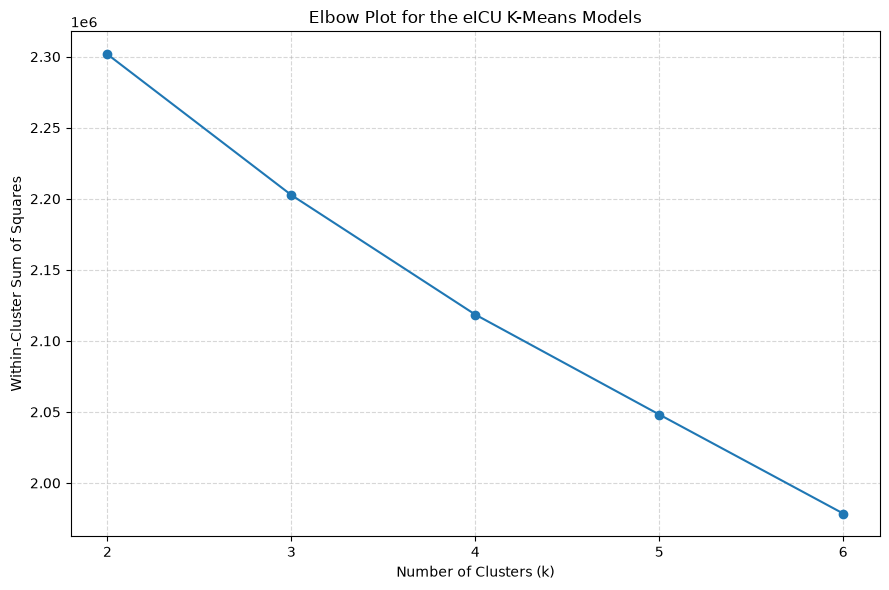

In [18]:
plt.figure(figsize=(9, 6))


plt.plot(
    model_comparison["k"],
    model_comparison["inertia_wcss"],
    marker="o",
)


plt.title(
    "Elbow Plot for the eICU K-Means Models"
)

plt.xlabel(
    "Number of Clusters (k)"
)

plt.ylabel(
    "Within-Cluster Sum of Squares"
)

plt.xticks(
    K_VALUES
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.5,
)

plt.tight_layout()


plt.savefig(
    MODEL_METRICS_PLOTS_DIR
    / "elbow_plot.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

#### Explanation :
The elbow plot shows how WCSS decreases as the number of clusters increases.

Look for a point where adding another cluster provides a noticeably smaller improvement than before. This point can be considered an elbow candidate, but it should not automatically become the selected value of `k`.

### Create the Silhouette Score Plot

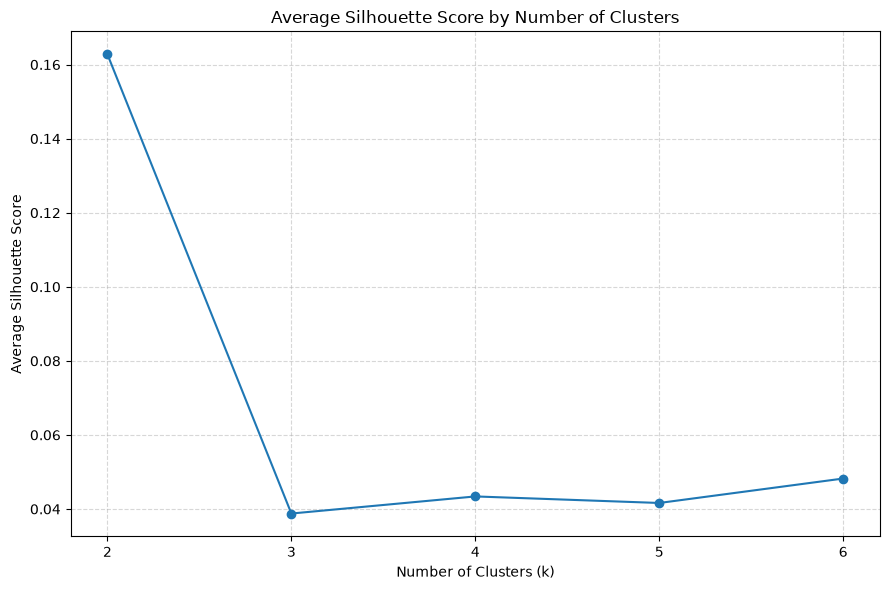

In [19]:
plt.figure(figsize=(9, 6))


plt.plot(
    model_comparison["k"],
    model_comparison[
        "average_silhouette"
    ],
    marker="o",
)


plt.title(
    "Average Silhouette Score by Number of Clusters"
)

plt.xlabel(
    "Number of Clusters (k)"
)

plt.ylabel(
    "Average Silhouette Score"
)

plt.xticks(
    K_VALUES
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.5,
)

plt.tight_layout()


plt.savefig(
    MODEL_METRICS_PLOTS_DIR
    / "silhouette_score_plot.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

#### Explanation :
This plot compares average cluster separation.

A larger silhouette score is generally preferred, but a slightly lower score may still be acceptable when the model has:

- More stable clusters
- Better cluster sizes
- More interpretable clinical profiles
- Greater clinical plausibility

### Plot the Additional Clustering Metrics

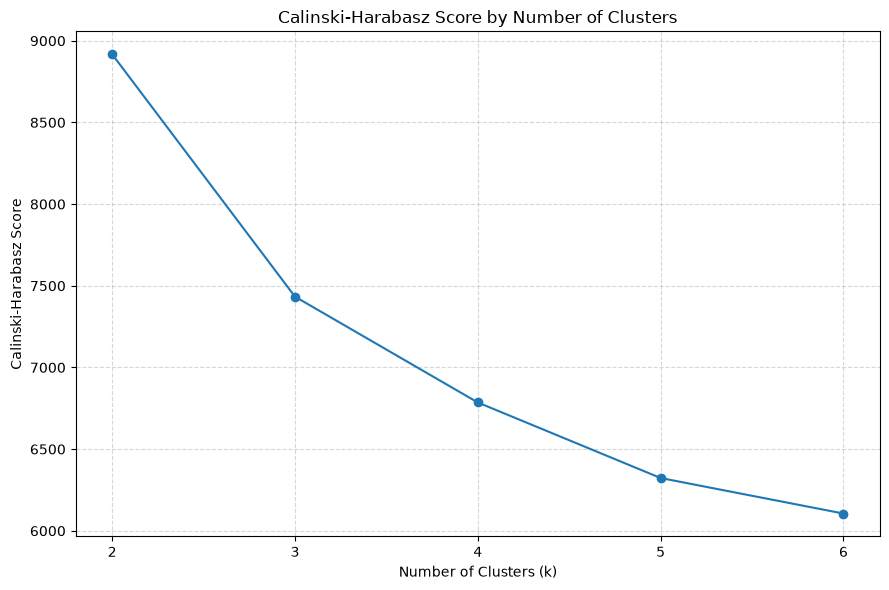

In [20]:
plt.figure(figsize=(9, 6))


plt.plot(
    model_comparison["k"],
    model_comparison[
        "calinski_harabasz_score"
    ],
    marker="o",
)


plt.title(
    "Calinski-Harabasz Score by Number of Clusters"
)

plt.xlabel(
    "Number of Clusters (k)"
)

plt.ylabel(
    "Calinski-Harabasz Score"
)

plt.xticks(
    K_VALUES
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.5,
)

plt.tight_layout()


plt.savefig(
    MODEL_METRICS_PLOTS_DIR
    / "calinski_harabasz_plot.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

#### Explanation :
A larger Calinski–Harabasz score generally represents more compact and better-separated clusters.

It is included as a supporting metric and should not be used alone.

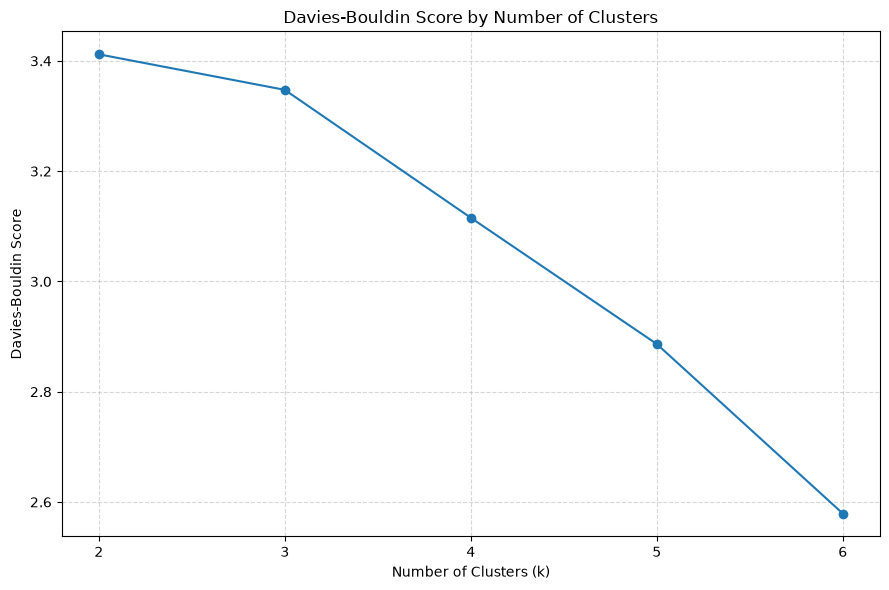

In [21]:
plt.figure(figsize=(9, 6))


plt.plot(
    model_comparison["k"],
    model_comparison[
        "davies_bouldin_score"
    ],
    marker="o",
)


plt.title(
    "Davies-Bouldin Score by Number of Clusters"
)

plt.xlabel(
    "Number of Clusters (k)"
)

plt.ylabel(
    "Davies-Bouldin Score"
)

plt.xticks(
    K_VALUES
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.5,
)

plt.tight_layout()


plt.savefig(
    MODEL_METRICS_PLOTS_DIR
    / "davies_bouldin_plot.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

#### Explanation :
A smaller Davies–Bouldin score is generally preferred.

This score is used only as supporting evidence together with WCSS, silhouette score, stability, cluster size, and clinical interpretation.

### Create Individual Silhouette Plots

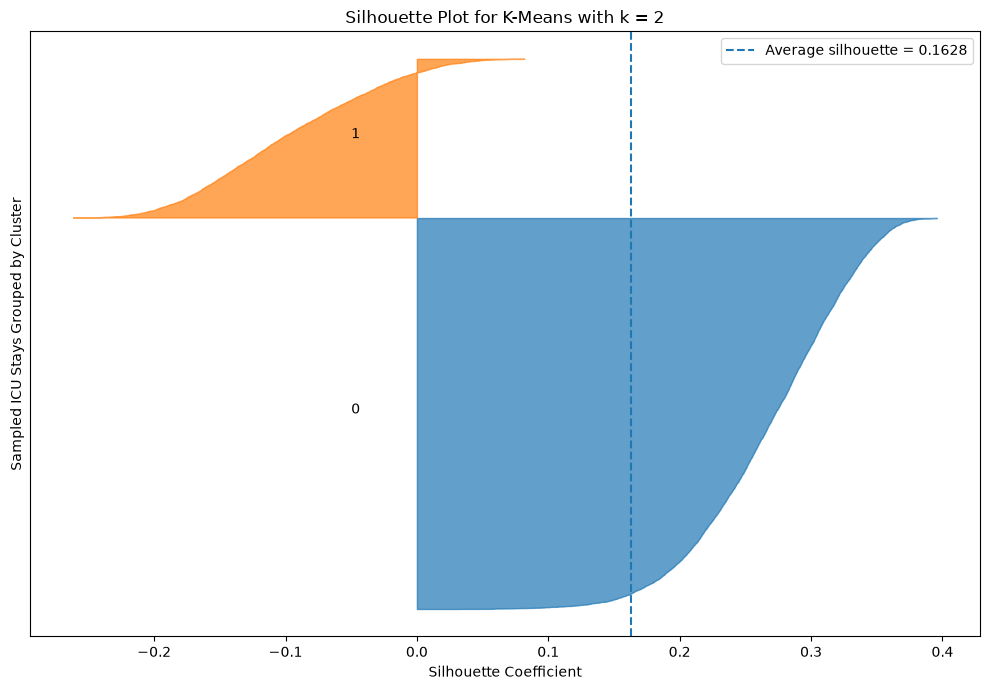

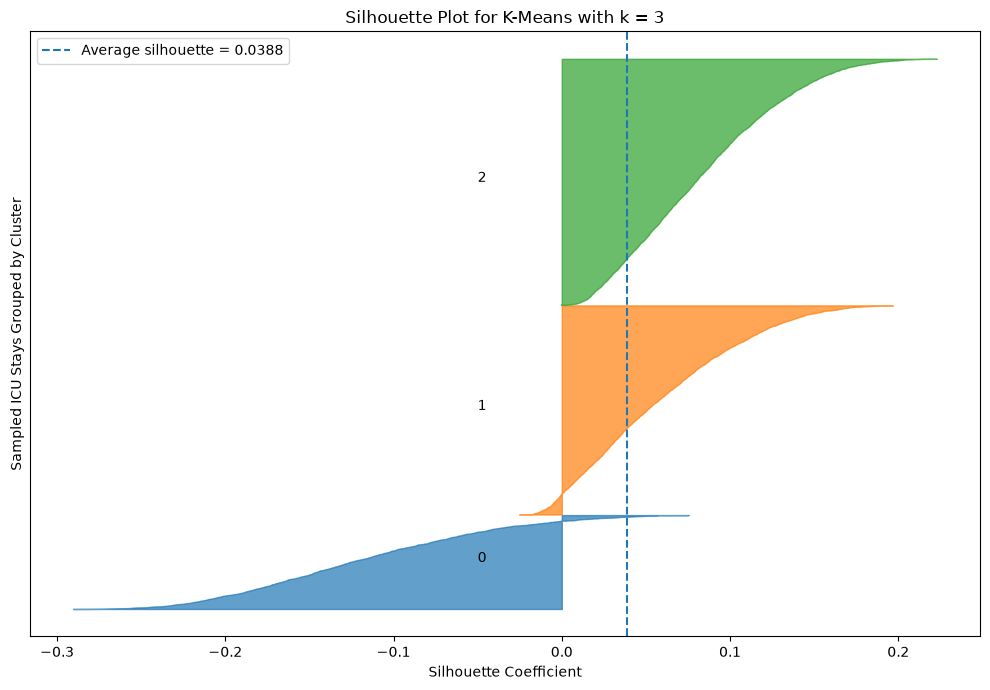

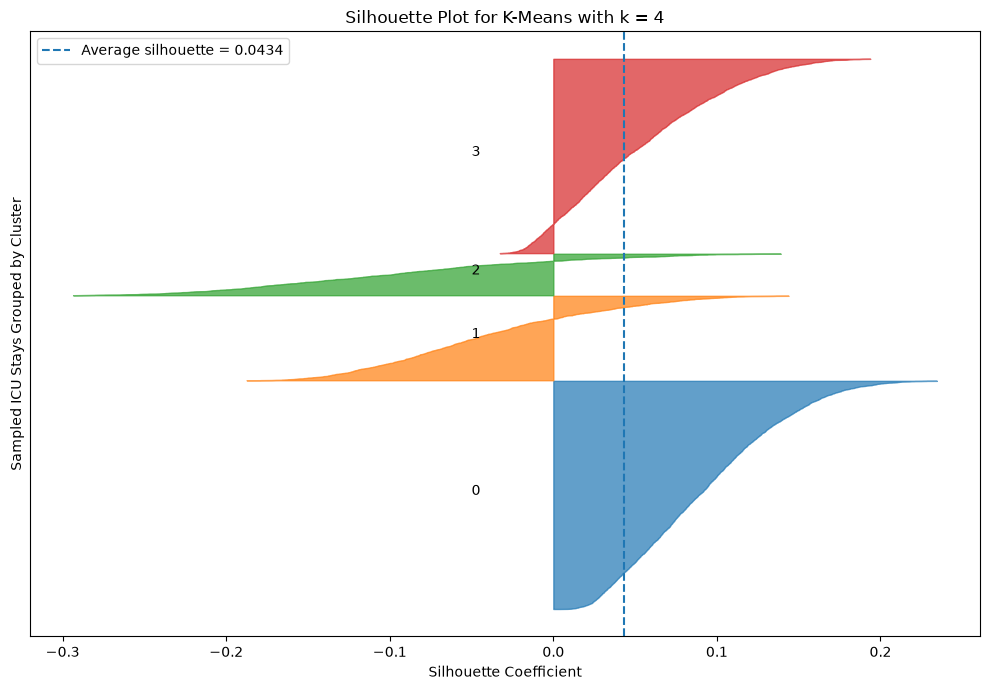

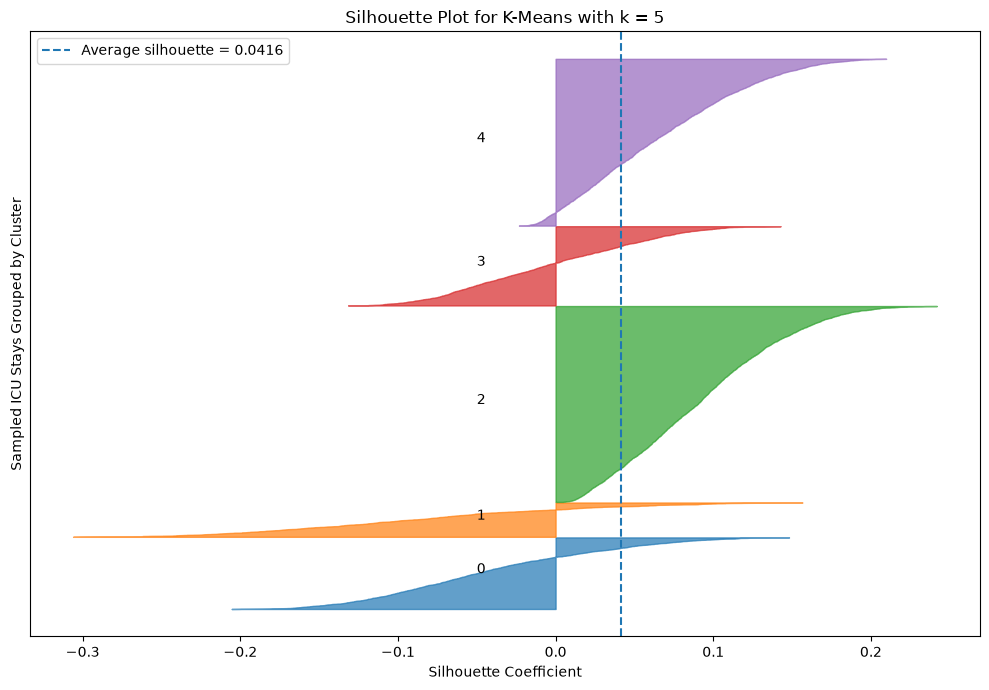

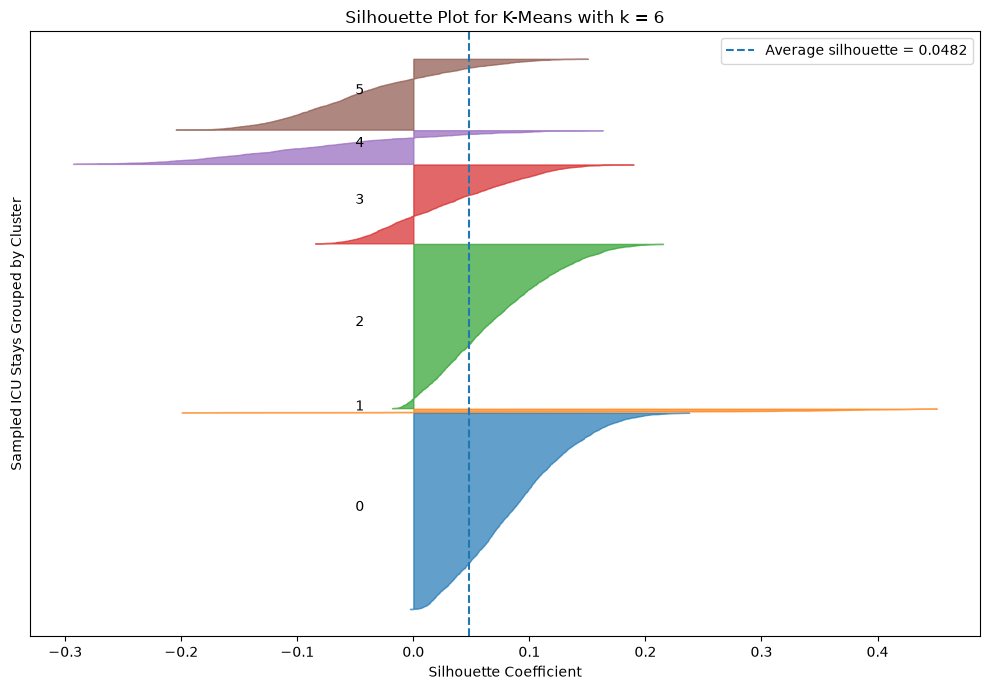

In [22]:
for k in K_VALUES:

    sampled_labels = (
        silhouette_values_by_k[k][
            "labels"
        ]
    )

    silhouette_values = (
        silhouette_values_by_k[k][
            "values"
        ]
    )

    average_silhouette = (
        silhouette_values_by_k[k][
            "average"
        ]
    )


    figure, axis = plt.subplots(
        figsize=(10, 7)
    )


    # Leave space between cluster sections
    y_lower = 10


    for cluster_number in range(k):

        cluster_silhouette_values = (
            silhouette_values[
                sampled_labels
                == cluster_number
            ]
        )


        cluster_silhouette_values.sort()


        cluster_sample_size = len(
            cluster_silhouette_values
        )


        y_upper = (
            y_lower
            + cluster_sample_size
        )


        cluster_color = plt.cm.tab10(
            cluster_number
            % 10
        )


        axis.fill_betweenx(
            np.arange(
                y_lower,
                y_upper,
            ),
            0,
            cluster_silhouette_values,
            facecolor=cluster_color,
            edgecolor=cluster_color,
            alpha=0.7,
        )


        axis.text(
            -0.05,
            y_lower
            + 0.5
            * cluster_sample_size,
            str(cluster_number),
        )


        y_lower = y_upper + 10


    axis.axvline(
        x=average_silhouette,
        linestyle="--",
        label=(
            "Average silhouette = "
            f"{average_silhouette:.4f}"
        ),
    )


    axis.set_title(
        f"Silhouette Plot for K-Means with k = {k}"
    )

    axis.set_xlabel(
        "Silhouette Coefficient"
    )

    axis.set_ylabel(
        "Sampled ICU Stays Grouped by Cluster"
    )

    axis.set_yticks([])

    axis.legend()

    plt.tight_layout()


    plt.savefig(
        SILHOUETTE_PLOTS_DIR
        / f"silhouette_k{k}.png",
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()

    plt.close()

#### Explanation :
Each silhouette plot shows the distribution of individual silhouette values within each cluster.

Review whether:

- Most values are positive
- Clusters have reasonable widths
- One cluster contains many negative values
- One cluster is much smaller than the others
- Cluster sections extend beyond the average silhouette line

The plots use the same fixed sample of ICU stays for every value of `k`.

### Create Cluster Size Plots

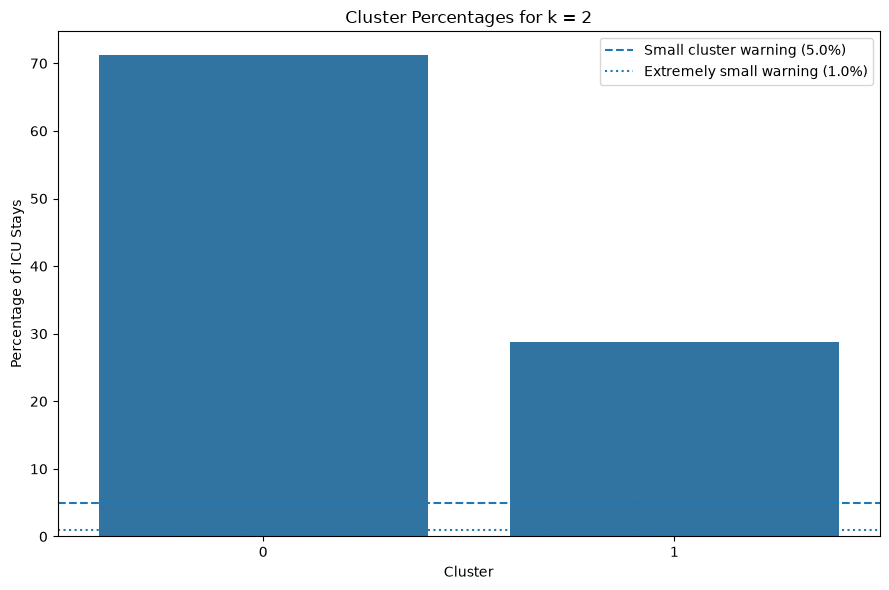

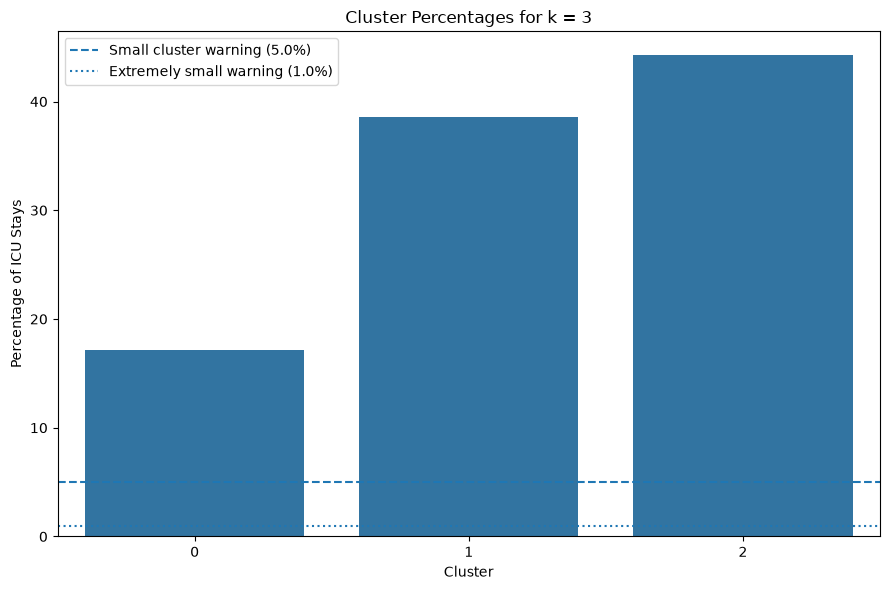

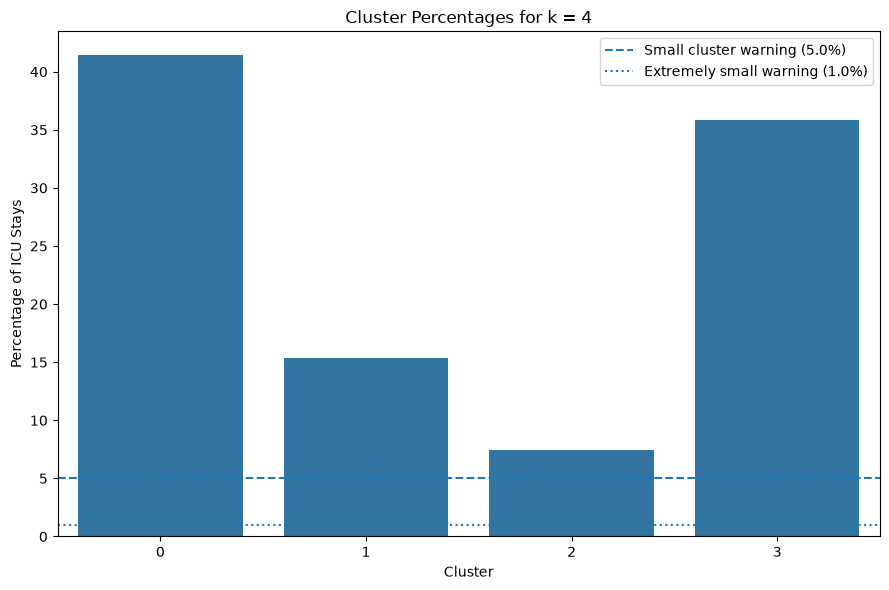

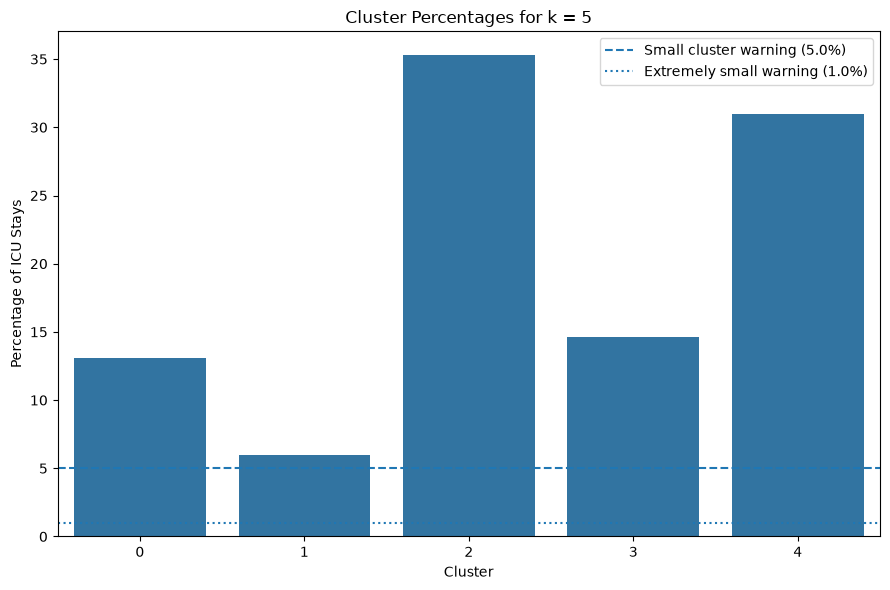

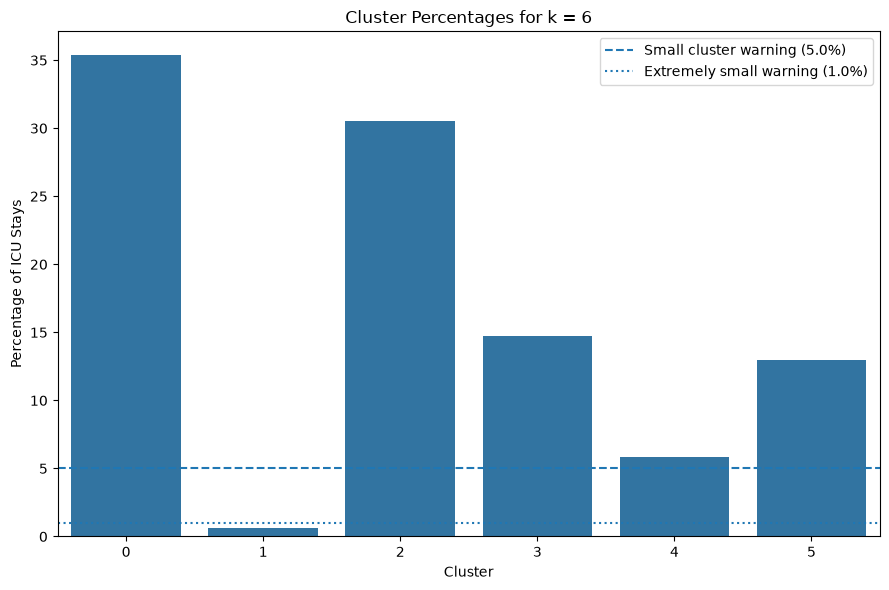

In [23]:
for k in K_VALUES:

    current_sizes = cluster_size_summary[
        cluster_size_summary["k"] == k
    ].copy()


    plt.figure(figsize=(9, 6))


    sns.barplot(
        data=current_sizes,
        x="cluster",
        y="observation_percent",
    )


    plt.axhline(
        SMALL_CLUSTER_PERCENT,
        linestyle="--",
        label=(
            f"Small cluster warning "
            f"({SMALL_CLUSTER_PERCENT}%)"
        ),
    )


    plt.axhline(
        EXTREMELY_SMALL_CLUSTER_PERCENT,
        linestyle=":",
        label=(
            "Extremely small warning "
            f"({EXTREMELY_SMALL_CLUSTER_PERCENT}%)"
        ),
    )


    plt.title(
        f"Cluster Percentages for k = {k}"
    )

    plt.xlabel(
        "Cluster"
    )

    plt.ylabel(
        "Percentage of ICU Stays"
    )

    plt.legend()

    plt.tight_layout()


    plt.savefig(
        CLUSTER_SIZE_PLOTS_DIR
        / f"cluster_sizes_k{k}.png",
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()

    plt.close()

#### Explanation :

These plot show the percentage of ICU stays in each cluster.

A small cluster is not automatically invalid. It may represent a genuine rare phenotype, but it can also indicate:
- Outliers
- Unstable partitioning
- Heavy imputation
- An overly large value of $k$

### Examine Stability Across Random Seeds

In [24]:
seed_run_rows = []
pairwise_stability_rows = []
stability_summary_rows = []


print("=" * 80)
print("TESTING STABILITY ACROSS RANDOM SEEDS")
print("=" * 80)


for k in K_VALUES:

    print(f"\nTesting stability for k = {k}")


    labels_by_seed = {}


    for seed in STABILITY_RANDOM_SEEDS:

        # Reuse the primary result for seed 42
        if seed == PRIMARY_RANDOM_SEED:

            seed_model = primary_models[k]
            seed_labels = primary_labels[k]

        else:

            seed_model = KMeans(
                n_clusters=k,
                init="k-means++",
                n_init=N_INIT,
                max_iter=MAX_ITERATIONS,
                random_state=seed,
                algorithm="lloyd",
            )


            seed_labels = seed_model.fit_predict(
                X
            )


        labels_by_seed[seed] = seed_labels


        # Compare this seed with the primary seed
        ari_vs_primary = adjusted_rand_score(
            primary_labels[k],
            seed_labels,
        )


        seed_sizes = summarize_cluster_sizes(
            cluster_labels=seed_labels,
            number_of_clusters=k,
        )


        seed_run_rows.append(
            {
                "k": k,
                "random_seed": seed,
                "inertia_wcss": seed_model.inertia_,
                "ari_vs_primary_seed": (
                    ari_vs_primary
                ),
                "smallest_cluster_percent": (
                    seed_sizes[
                        "observation_percent"
                    ].min()
                ),
                "any_extremely_small_cluster": (
                    seed_sizes[
                        "extremely_small_cluster"
                    ].any()
                ),
            }
        )


    # Compare every pair of seed solutions
    pairwise_ari_values = []


    for first_seed, second_seed in combinations(
        STABILITY_RANDOM_SEEDS,
        2,
    ):

        pairwise_ari = adjusted_rand_score(
            labels_by_seed[first_seed],
            labels_by_seed[second_seed],
        )


        pairwise_ari_values.append(
            pairwise_ari
        )


        pairwise_stability_rows.append(
            {
                "k": k,
                "first_seed": first_seed,
                "second_seed": second_seed,
                "adjusted_rand_index": (
                    pairwise_ari
                ),
            }
        )


    mean_pairwise_ari = float(
        np.mean(pairwise_ari_values)
    )


    minimum_pairwise_ari = float(
        np.min(pairwise_ari_values)
    )


    maximum_pairwise_ari = float(
        np.max(pairwise_ari_values)
    )


    stable_solution = bool(
        (
            mean_pairwise_ari
            >= STABLE_MEAN_ARI_THRESHOLD
        )
        and
        (
            minimum_pairwise_ari
            >= STABLE_MINIMUM_ARI_THRESHOLD
        )
    )


    stability_summary_rows.append(
        {
            "k": k,
            "mean_pairwise_ari": (
                mean_pairwise_ari
            ),
            "minimum_pairwise_ari": (
                minimum_pairwise_ari
            ),
            "maximum_pairwise_ari": (
                maximum_pairwise_ari
            ),
            "stable_solution": (
                stable_solution
            ),
        }
    )


    print(
        f"k = {k} | "
        f"Mean ARI = {mean_pairwise_ari:.4f} | "
        f"Minimum ARI = {minimum_pairwise_ari:.4f} | "
        f"Stable = {stable_solution}"
    )

TESTING STABILITY ACROSS RANDOM SEEDS

Testing stability for k = 2
k = 2 | Mean ARI = 0.9897 | Minimum ARI = 0.9821 | Stable = True

Testing stability for k = 3
k = 3 | Mean ARI = 0.9794 | Minimum ARI = 0.9531 | Stable = True

Testing stability for k = 4
k = 4 | Mean ARI = 0.9906 | Minimum ARI = 0.9828 | Stable = True

Testing stability for k = 5
k = 5 | Mean ARI = 0.9840 | Minimum ARI = 0.9723 | Stable = True

Testing stability for k = 6
k = 6 | Mean ARI = 0.6778 | Minimum ARI = 0.4518 | Stable = False


#### Explanation :
Each value of `k` is fitted using five random seeds.

The Adjusted Rand Index compares patient assignments between the different runs. It is appropriate because a cluster called `0` in one model can be called `2` in another model without representing a different partition.

The notebook marks a solution as stable when:
```
Mean pairwise ARI ≥ 0.90
Minimum pairwise ARI ≥ 0.80
```

These thresholds are documented working rules and can be changed if your research protocol uses different criteria.

### Save the Stability Results

In [25]:
seed_stability_runs = pd.DataFrame(
    seed_run_rows
)


seed_stability_pairwise = pd.DataFrame(
    pairwise_stability_rows
)


seed_stability_summary = pd.DataFrame(
    stability_summary_rows
)


seed_stability_runs.to_csv(
    RESULTS_DIR / "seed_stability_runs.csv",
    index=False,
)


seed_stability_pairwise.to_csv(
    RESULTS_DIR / "seed_stability_pairwise.csv",
    index=False,
)


seed_stability_summary.to_csv(
    RESULTS_DIR / "seed_stability_summary.csv",
    index=False,
)


seed_stability_summary

,k,mean_pairwise_ari,minimum_pairwise_ari,maximum_pairwise_ari,stable_solution
0,2,0.989688,0.982120,0.996184,True
1,3,0.979416,0.953122,0.999082,True
2,4,0.990593,0.982843,0.999354,True
3,5,0.983983,0.972341,0.999669,True
4,6,0.677785,0.451754,0.979411,False


#### Explanation :
Three stability tables are saved:
- Results from every individual seed
- Pairwise ARI comparisons
- Overall stability summary for each value of `k`

### Add Stability to the Main Comparison Table

In [26]:
model_comparison = model_comparison.merge(
    seed_stability_summary,
    on="k",
    how="left",
    validate="one_to_one",
)


model_comparison.to_csv(
    RESULTS_DIR
    / "kmeans_model_comparison.csv",
    index=False,
)


model_comparison

,k,inertia_wcss,average_silhouette,silhouette_sample_size,calinski_harabasz_score,davies_bouldin_score,smallest_cluster_count,smallest_cluster_percent,any_small_cluster,any_extremely_small_cluster,iterations,wcss_reduction_from_previous_percent,mean_pairwise_ari,minimum_pairwise_ari,maximum_pairwise_ari,stable_solution
0,2,2.301674e+06,0.162776,10000,8917.186702,3.411967,35572,28.826580,False,False,29,NaN,0.989688,0.982120,0.996184,True
1,3,2.202629e+06,0.038775,10000,7433.422774,3.347465,21214,17.191248,False,False,32,4.303167,0.979416,0.953122,0.999082,True
2,4,2.118510e+06,0.043393,10000,6785.552931,3.115490,9173,7.433549,False,False,35,3.819049,0.990593,0.982843,0.999354,True
3,5,2.048183e+06,0.041627,10000,6323.086822,2.886491,7382,5.982172,False,False,70,3.319626,0.983983,0.972341,0.999669,True
4,6,1.978514e+06,0.048226,10000,6105.592712,2.579104,751,0.608590,True,True,34,3.401535,0.677785,0.451754,0.979411,False


#### Explanation :

The main comparison table now contains:

- WCSS
- WCSS improvement
- Silhouette score
- Calinski–Harabasz score
- Davies–Bouldin score
- Smallest cluster size
- Small-cluster warnings
- Seed stability
- Number of model iterations

### Create the Stability Plot

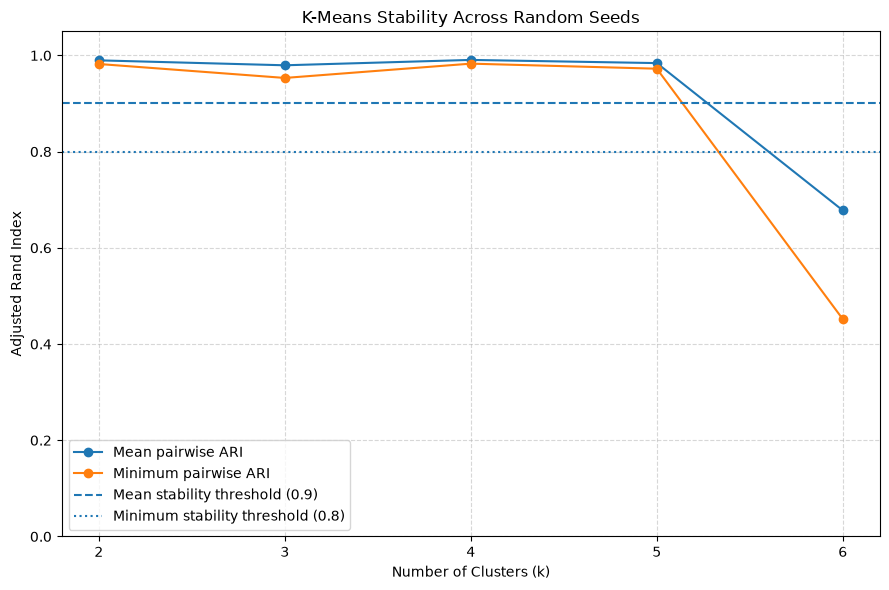

In [27]:
plt.figure(figsize=(9, 6))


plt.plot(
    seed_stability_summary["k"],
    seed_stability_summary[
        "mean_pairwise_ari"
    ],
    marker="o",
    label="Mean pairwise ARI",
)


plt.plot(
    seed_stability_summary["k"],
    seed_stability_summary[
        "minimum_pairwise_ari"
    ],
    marker="o",
    label="Minimum pairwise ARI",
)


plt.axhline(
    STABLE_MEAN_ARI_THRESHOLD,
    linestyle="--",
    label=(
        "Mean stability threshold "
        f"({STABLE_MEAN_ARI_THRESHOLD})"
    ),
)


plt.axhline(
    STABLE_MINIMUM_ARI_THRESHOLD,
    linestyle=":",
    label=(
        "Minimum stability threshold "
        f"({STABLE_MINIMUM_ARI_THRESHOLD})"
    ),
)


plt.title(
    "K-Means Stability Across Random Seeds"
)

plt.xlabel(
    "Number of Clusters (k)"
)

plt.ylabel(
    "Adjusted Rand Index"
)

plt.xticks(
    K_VALUES
)

plt.ylim(
    0,
    1.05,
)

plt.legend()

plt.grid(
    True,
    linestyle="--",
    alpha=0.5,
)

plt.tight_layout()


plt.savefig(
    STABILITY_PLOTS_DIR
    / "seed_stability.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

#### Explanation :
The stability plot compares the average and worst pairwise agreement across random seeds.

A model with good quantitative separation but poor seed stability should not normally be preferred without a clear explanation.

### Create a Two-Dimensional PCA Representation

In [28]:
# Fit PCA using all standardized observations
pca_model = PCA(
    n_components=2,
)


pca_coordinates = pca_model.fit_transform(
    X
)


pca_explained_variance = pd.DataFrame(
    {
        "component": [
            "PC1",
            "PC2",
        ],
        "explained_variance_ratio": (
            pca_model.explained_variance_ratio_
        ),
    }
)


pca_explained_variance[
    "explained_variance_percent"
] = (
    pca_explained_variance[
        "explained_variance_ratio"
    ]
    * 100
)


pca_explained_variance.to_csv(
    RESULTS_DIR
    / "pca_explained_variance.csv",
    index=False,
)


pca_explained_variance

,component,explained_variance_ratio,explained_variance_percent
0,PC1,0.110012,11.001167
1,PC2,0.083925,8.392504


#### Explanation :
PCA reduces the $20$ standardized variables to two visual dimensions.

The PCA coordinates are used only for visualization. K-Means remains fitted on the full 20-variable standardized matrix.

Scikit-learn describes PCA as a linear dimensionality-reduction method that projects centered data onto directions of maximum variance.

### Select a Reproducible Sample for PCA Plots

In [29]:
pca_sample_generator = np.random.default_rng(
    PRIMARY_RANDOM_SEED
)


actual_pca_sample_size = min(
    PCA_PLOT_SAMPLE_SIZE,
    len(X),
)


pca_sample_indices = pca_sample_generator.choice(
    len(X),
    size=actual_pca_sample_size,
    replace=False,
)


pca_sample_indices = np.sort(
    pca_sample_indices
)


pca_plot_data = pd.DataFrame(
    {
        "PC1": pca_coordinates[
            pca_sample_indices,
            0,
        ],
        "PC2": pca_coordinates[
            pca_sample_indices,
            1,
        ],
        ID_COLUMN: row_ids.iloc[
            pca_sample_indices
        ][ID_COLUMN].to_numpy(),
    }
)


pca_plot_data.to_csv(
    RESULTS_DIR
    / "pca_plot_sample_coordinates.csv",
    index=False,
)


print(
    "PCA plotting sample size:",
    len(pca_plot_data),
)

PCA plotting sample size: 10000


#### Explanation :
The PCA model is fitted using the complete matrix, but only $10,000$ observations are displayed.

This keeps the scatter plots readable while preserving reproducibility.

### Create PCA Cluster Plots

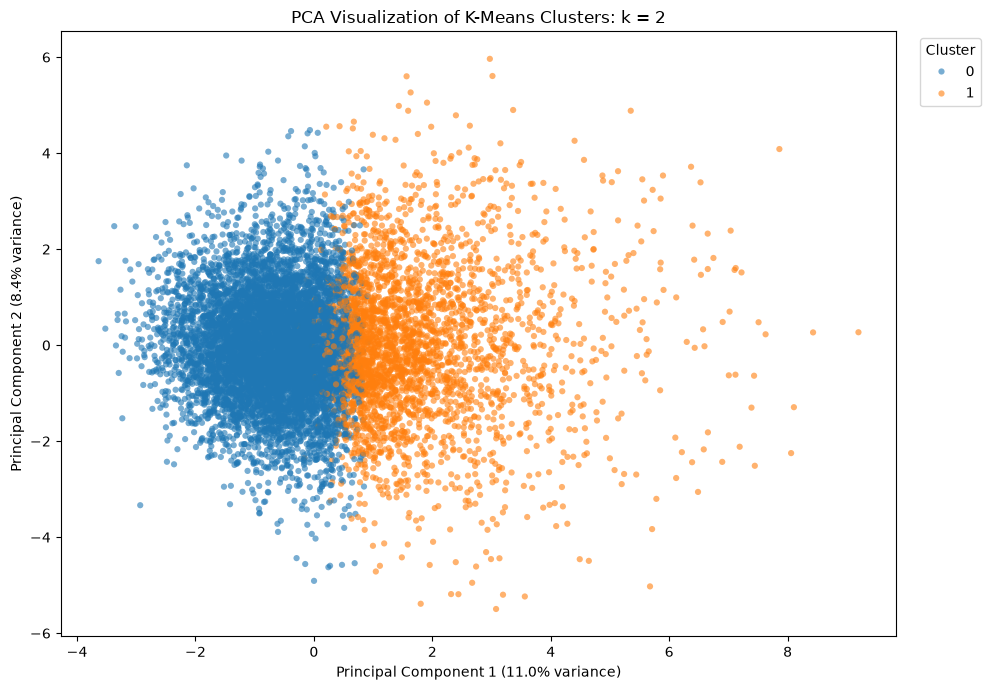

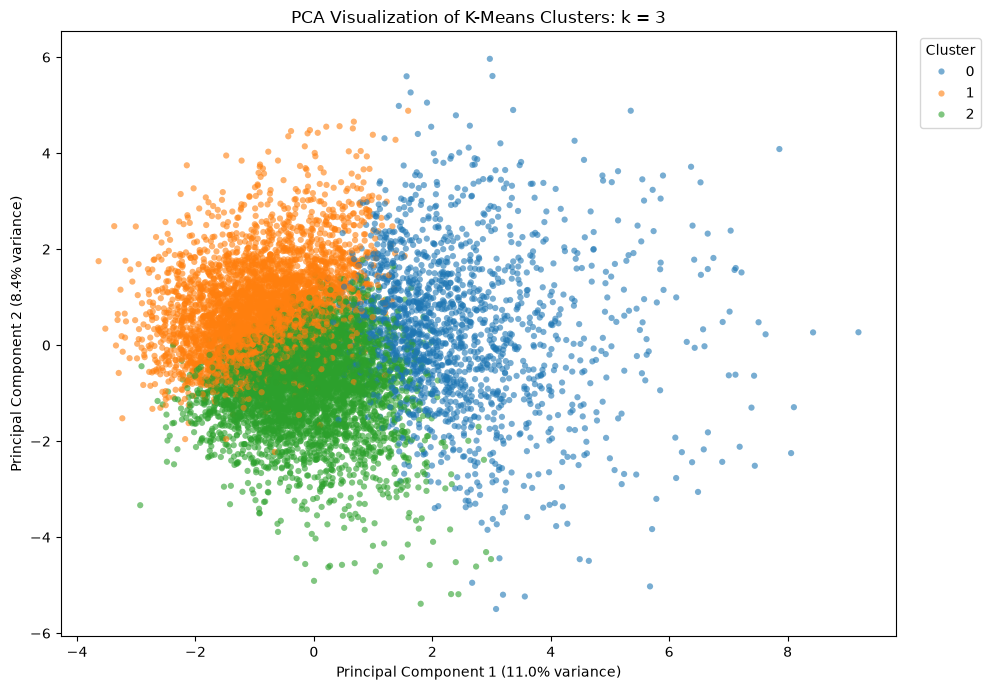

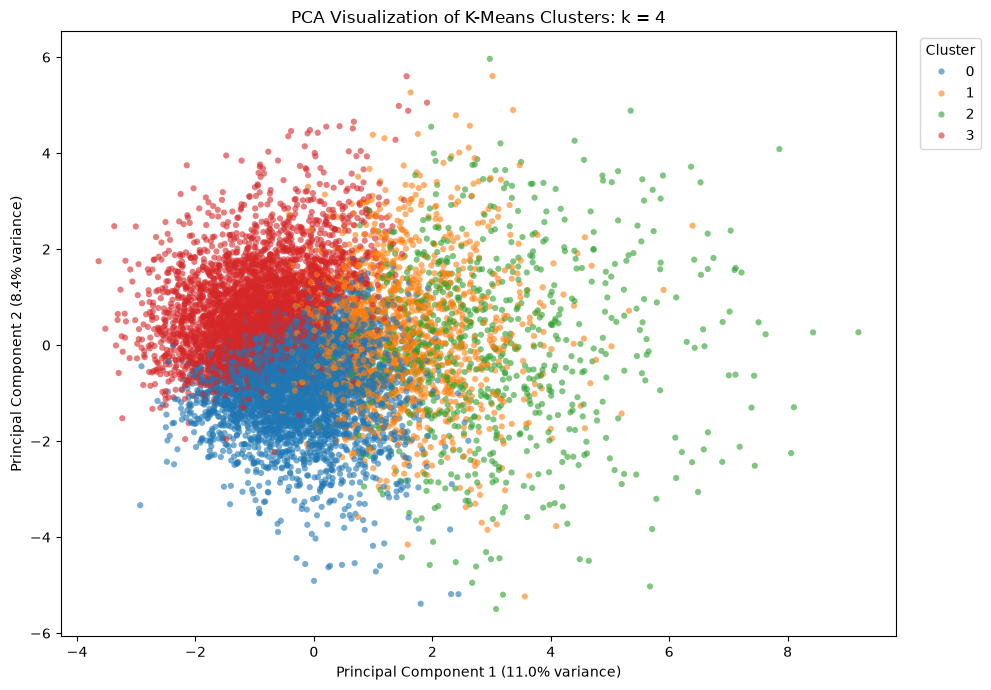

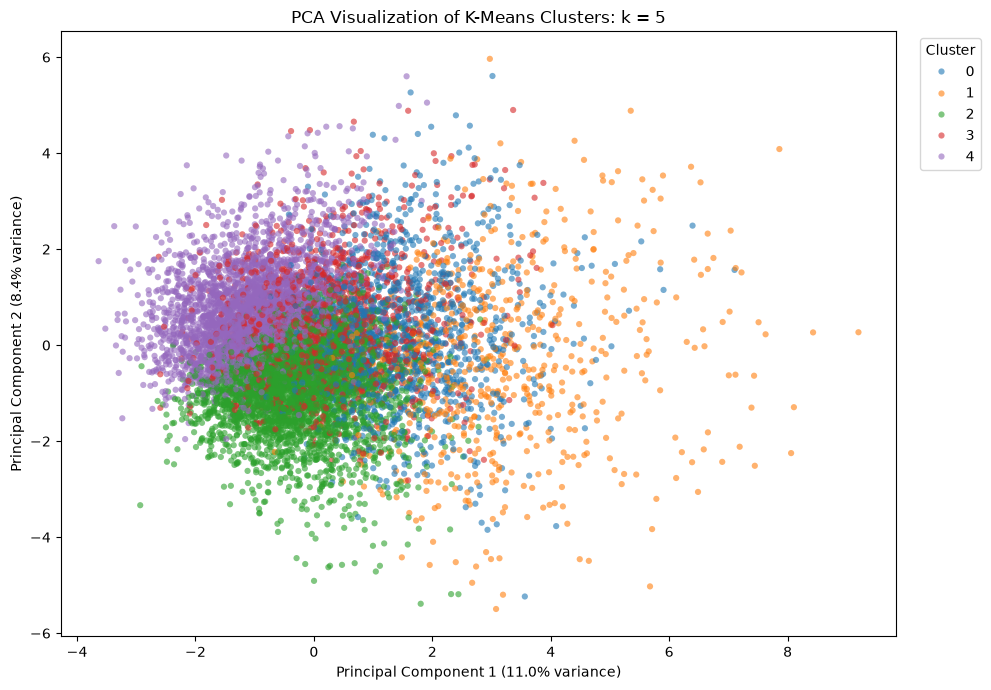

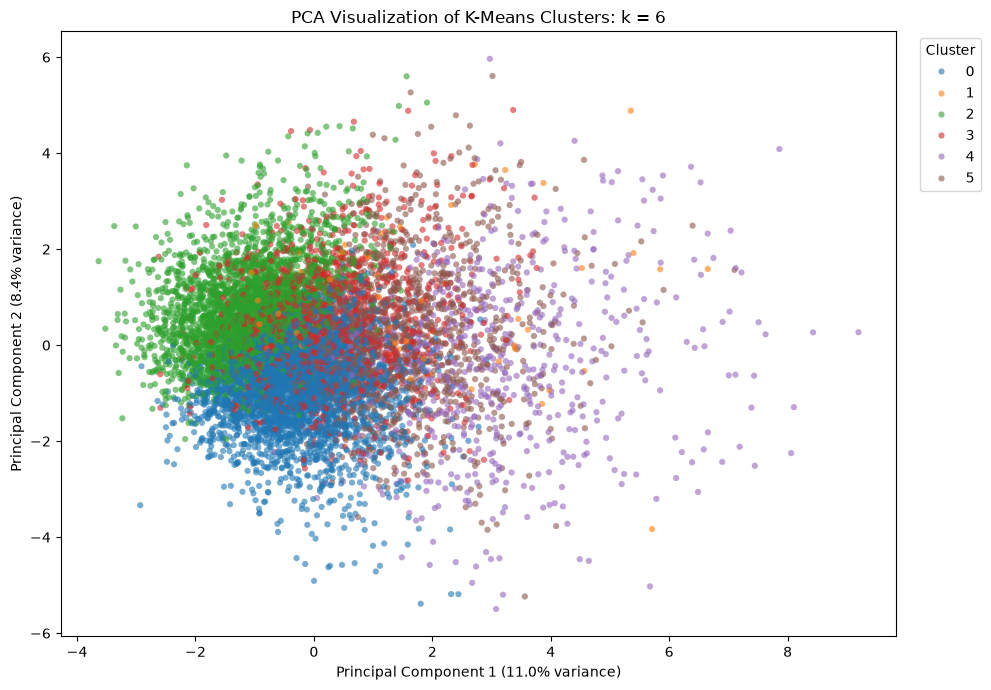

In [30]:
for k in K_VALUES:

    current_pca_data = (
        pca_plot_data.copy()
    )


    current_pca_data["cluster"] = (
        primary_labels[k][
            pca_sample_indices
        ]
    )


    plt.figure(figsize=(10, 7))


    sns.scatterplot(
        data=current_pca_data,
        x="PC1",
        y="PC2",
        hue="cluster",
        palette="tab10",
        s=20,
        alpha=0.6,
        linewidth=0,
    )


    pc1_percent = (
        pca_model.explained_variance_ratio_[
            0
        ]
        * 100
    )

    pc2_percent = (
        pca_model.explained_variance_ratio_[
            1
        ]
        * 100
    )


    plt.title(
        f"PCA Visualization of K-Means Clusters: k = {k}"
    )

    plt.xlabel(
        f"Principal Component 1 "
        f"({pc1_percent:.1f}% variance)"
    )

    plt.ylabel(
        f"Principal Component 2 "
        f"({pc2_percent:.1f}% variance)"
    )

    plt.legend(
        title="Cluster",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    plt.tight_layout()


    plt.savefig(
        PCA_PLOTS_DIR
        / f"pca_clusters_k{k}.png",
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()

    plt.close()

#### Explanation :
These plots provide a visual view of the clusters in two PCA dimensions.

Overlapping points in PCA do not necessarily mean that the clusters are invalid because K-Means was fitted in 20 dimensions and PCA shows only part of the variation.

### Create Standardized Cluster Profile Heatmaps

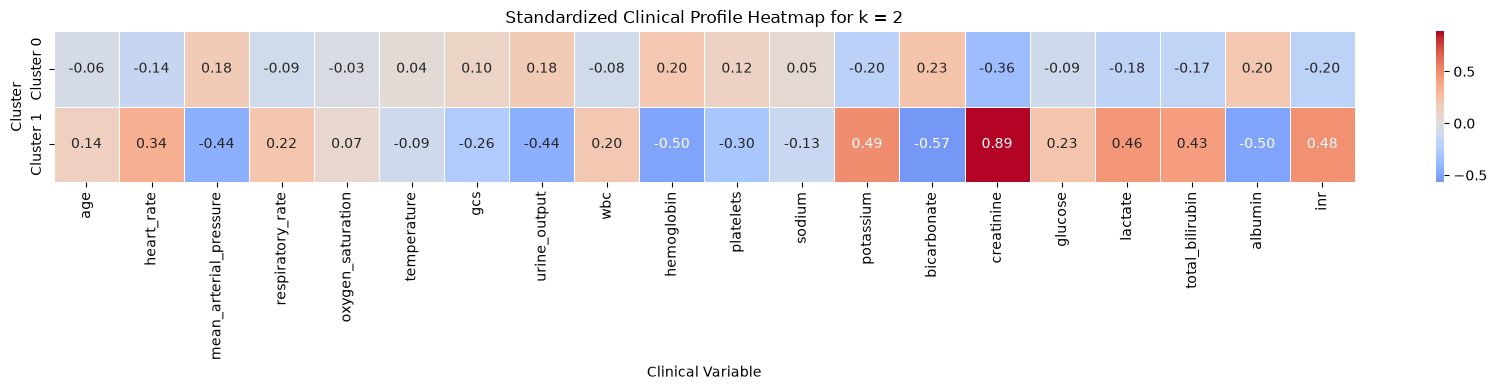

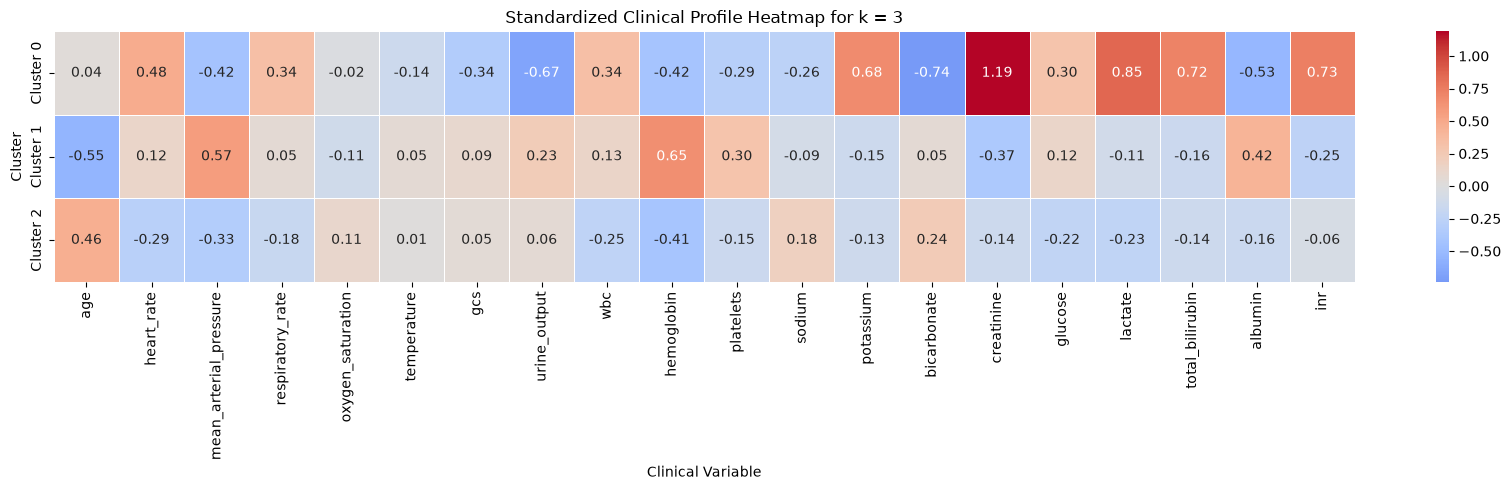

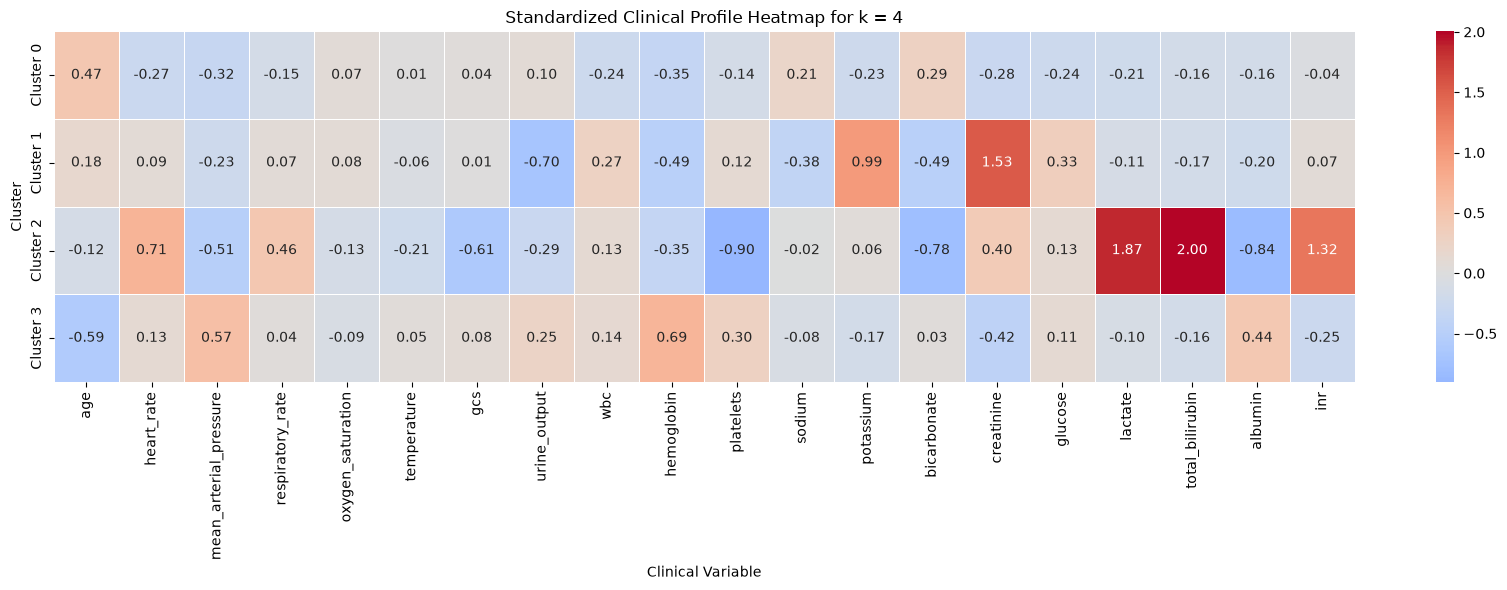

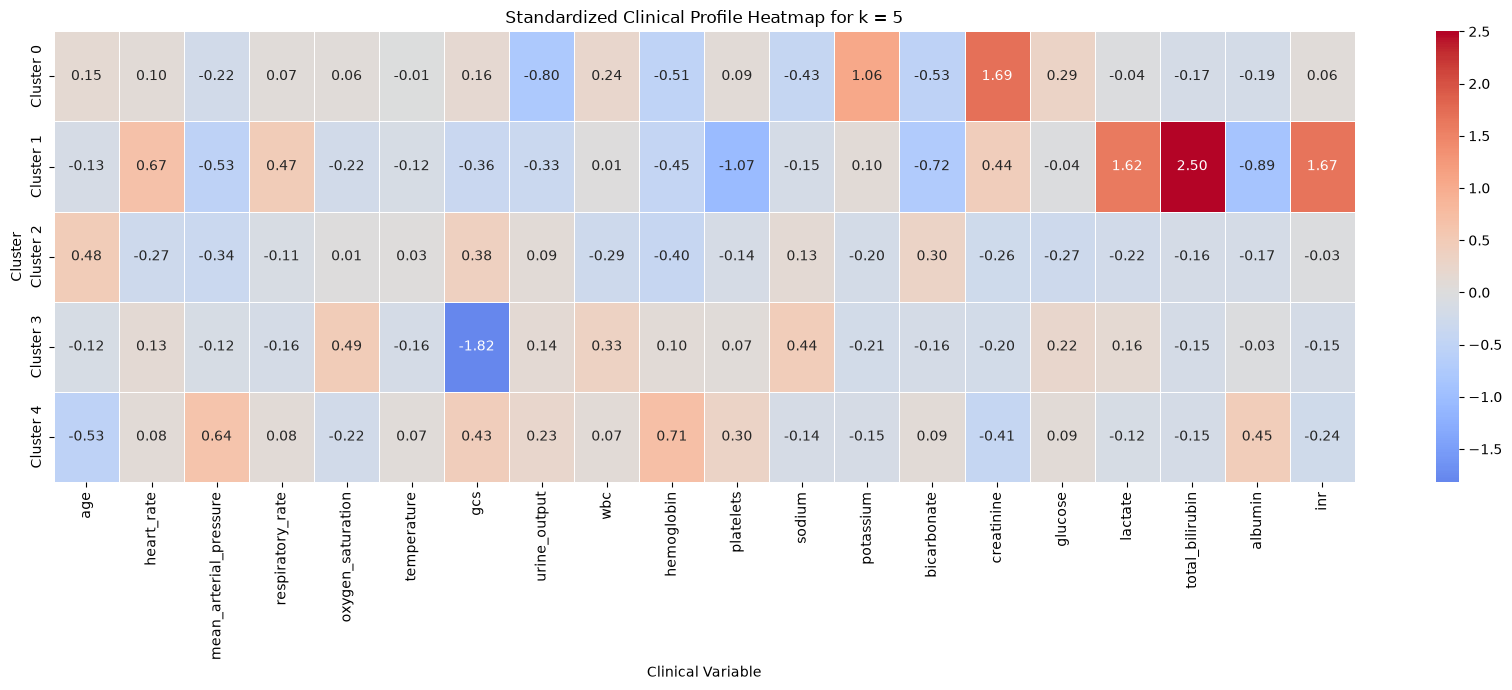

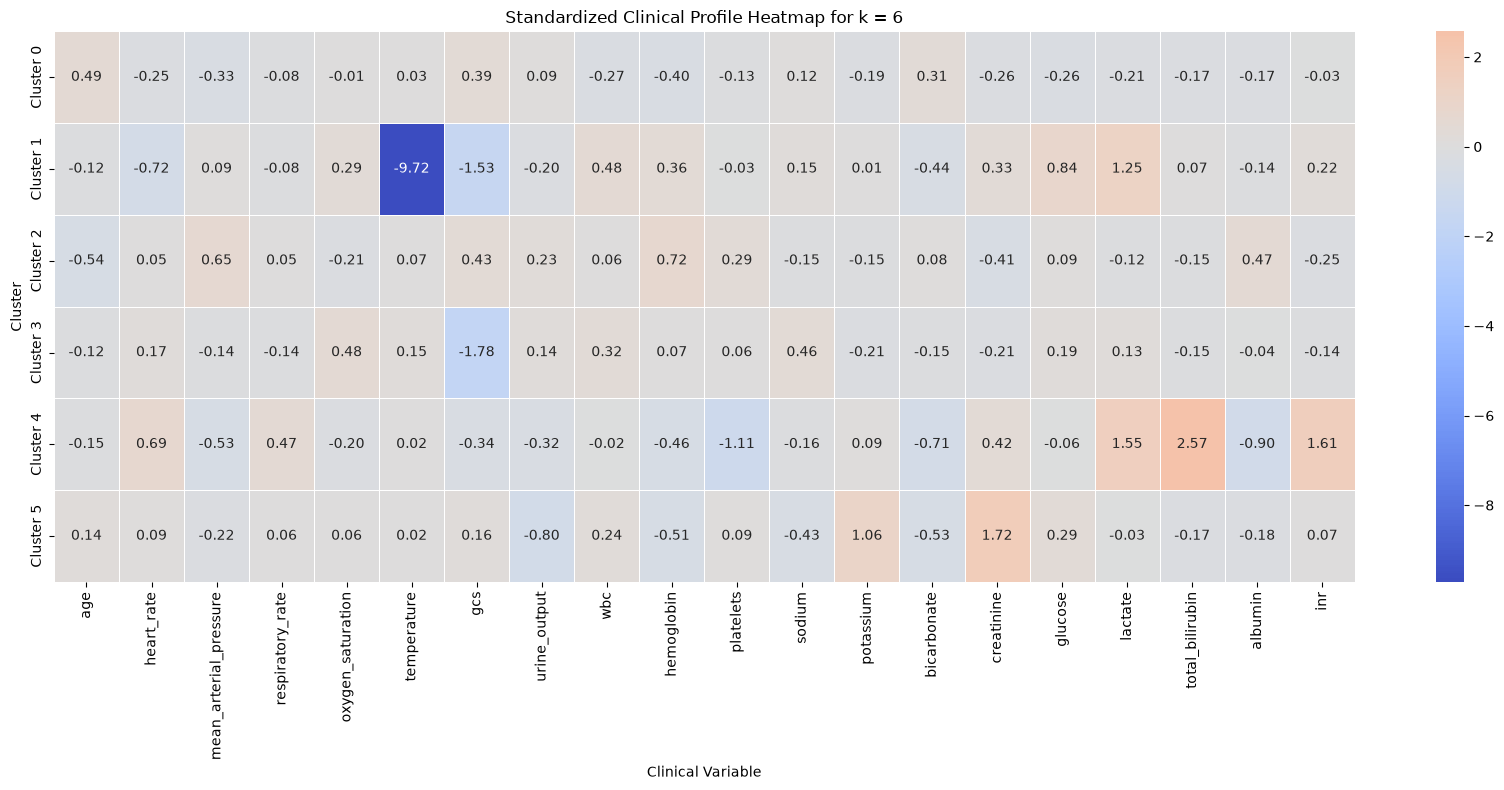

In [31]:
for k in K_VALUES:

    current_model = primary_models[k]


    center_table = pd.DataFrame(
        current_model.cluster_centers_,
        columns=FEATURES,
        index=[
            f"Cluster {cluster_number}"
            for cluster_number in range(k)
        ],
    )


    plt.figure(
        figsize=(17, 2 + k)
    )


    sns.heatmap(
        center_table,
        cmap="coolwarm",
        center=0,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
    )


    plt.title(
        f"Standardized Clinical Profile Heatmap for k = {k}"
    )

    plt.xlabel(
        "Clinical Variable"
    )

    plt.ylabel(
        "Cluster"
    )

    plt.tight_layout()


    plt.savefig(
        CLINICAL_PROFILE_PLOTS_DIR
        / f"standardized_profile_k{k}.png",
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()

    plt.close()

#### Explanation :
Each heatmap displays the standardized center of every cluster.

Interpretation:

- Positive values indicate that the cluster center is above the overall feature mean
- Negative values indicate that it is below the overall feature mean
- Values near zero indicate that it is close to the overall mean

These plots help determine whether the clusters represent understandable clinical patterns.

### Display Clinical Medians in a Wide Table

In [32]:
clinical_median_tables = {}


for k in K_VALUES:

    current_profile = (
        clinical_profile_summary[
            clinical_profile_summary["k"] == k
        ]
    )


    median_table = current_profile.pivot(
        index="cluster",
        columns="variable",
        values="median",
    )


    # Keep variables in the original feature order
    median_table = median_table[
        FEATURES
    ]


    clinical_median_tables[k] = (
        median_table
    )


    median_table.to_csv(
        CLINICAL_PROFILES_DIR
        / f"clinical_medians_k{k}.csv"
    )


print(
    "Clinical median tables were saved "
    "for every value of k."
)

Clinical median tables were saved for every value of k.


#### Explanation :
These tables describe cluster centers in understandable clinical units.

For example, they can reveal whether a cluster has:

- Low mean arterial pressure
- High lactate
- Reduced GCS
- Increased creatinine
- Low platelets
- Abnormal bilirubin or INR

These profiles are required for judging interpretability and clinical plausibility.

### Display One Clinical Profile at a Time

In [33]:
# Change this value to display another model
K_TO_DISPLAY = 2


clinical_median_tables[
    K_TO_DISPLAY
].round(2)

variable,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,urine_output,wbc,hemoglobin,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
cluster,,,,,,,,,,,,,,,,,,,,
0,65.0,82.36,81.56,18.98,97.03,37.12,14.0,1400.0,10.7,11.3,191.0,139.0,4.0,25.0,0.90,126.0,1.7,0.62,2.9,1.3
1,68.0,90.09,73.34,19.62,97.36,37.12,14.0,1400.0,11.9,9.7,174.0,138.0,4.3,21.0,1.92,137.0,1.7,0.62,2.9,1.3


#### Explanation :
This cell allows you to inspect the clinical median profile for a particular value of `k`

In [34]:
K_TO_DISPLAY = 3


clinical_median_tables[
    K_TO_DISPLAY
].round(2)

variable,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,urine_output,wbc,hemoglobin,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
cluster,,,,,,,,,,,,,,,,,,,,
0,66.0,92.64,73.43,20.22,97.22,37.12,14.0,1210.0,12.80,9.9,176.0,137.0,4.5,20.0,2.37,142.0,1.7,0.62,2.9,1.3
1,56.0,86.42,87.21,18.98,96.83,37.12,14.0,1400.0,11.06,12.4,209.0,138.0,4.0,24.0,0.87,132.0,1.7,0.62,2.9,1.3
2,73.0,80.00,75.40,18.70,97.23,37.12,14.0,1400.0,9.90,10.1,181.0,139.0,4.0,25.0,1.00,122.0,1.7,0.62,2.9,1.3


In [35]:
K_TO_DISPLAY = 4


clinical_median_tables[
    K_TO_DISPLAY
].round(2)

variable,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,urine_output,wbc,hemoglobin,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
cluster,,,,,,,,,,,,,,,,,,,,
0,73.0,80.26,75.61,18.82,97.15,37.12,14.0,1400.0,9.90,10.2,181.0,139.0,3.9,25.0,0.96,121.0,1.70,0.62,2.9,1.3
1,68.0,85.83,75.73,18.98,97.30,37.12,14.0,1270.0,11.87,9.7,191.0,137.0,4.7,22.0,3.03,142.0,1.70,0.62,2.9,1.3
2,63.0,96.96,72.73,20.92,97.10,37.12,13.0,1400.0,12.20,10.0,130.0,138.0,4.0,20.0,1.50,134.0,3.17,1.70,2.5,1.6
3,55.0,86.45,87.28,18.98,96.88,37.12,14.0,1400.0,11.10,12.5,209.0,138.0,4.0,24.0,0.86,131.0,1.70,0.62,2.9,1.3


In [36]:
K_TO_DISPLAY = 5


clinical_median_tables[
    K_TO_DISPLAY
].round(2)

variable,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,urine_output,wbc,hemoglobin,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
cluster,,,,,,,,,,,,,,,,,,,,
0,67.5,85.96,75.78,18.98,97.25,37.12,14.0,1200.0,11.6,9.7,191.0,136.0,4.7,21.05,3.37,139.0,1.7,0.62,2.9,1.3
1,62.0,96.29,72.40,20.96,97.01,37.12,14.0,1400.0,11.5,9.8,117.0,138.0,4.1,20.00,1.56,127.0,2.4,2.50,2.5,1.7
2,73.0,80.20,75.43,18.98,97.09,37.12,14.0,1400.0,9.6,10.1,183.0,139.0,4.0,25.00,0.98,119.0,1.7,0.62,2.9,1.3
3,64.0,86.21,77.88,18.55,98.27,37.12,7.0,1400.0,12.6,11.0,191.0,140.0,3.9,23.00,1.00,139.0,1.7,0.62,2.9,1.3
4,56.0,85.54,88.25,18.98,96.57,37.12,14.0,1400.0,10.8,12.6,208.0,138.0,4.0,24.00,0.86,130.0,1.7,0.62,2.9,1.3


In [37]:
K_TO_DISPLAY = 6


clinical_median_tables[
    K_TO_DISPLAY
].round(2)

variable,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,urine_output,wbc,hemoglobin,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
cluster,,,,,,,,,,,,,,,,,,,,
0,73.0,80.38,75.46,18.98,97.06,37.12,14.0,1400.0,9.70,10.1,184.0,139.0,4.0,25.0,0.98,119.0,1.7,0.62,2.9,1.3
1,64.0,72.10,80.42,18.89,98.43,33.39,3.0,1400.0,14.60,11.7,191.0,139.0,4.0,21.2,1.35,181.0,2.0,0.62,2.9,1.3
2,56.0,85.23,88.38,18.98,96.60,37.12,14.0,1400.0,10.80,12.6,207.0,138.0,4.0,24.0,0.86,130.0,1.7,0.62,2.9,1.3
3,64.0,86.91,77.65,18.59,98.23,37.12,7.0,1400.0,12.48,11.0,191.0,140.0,3.9,23.0,0.99,138.0,1.7,0.62,2.9,1.3
4,62.0,96.51,72.39,20.94,97.02,37.12,14.0,1400.0,11.30,9.8,115.0,138.0,4.1,20.0,1.53,126.0,2.3,2.60,2.4,1.7
5,67.0,85.89,75.80,18.98,97.25,37.12,14.0,1200.0,11.60,9.7,191.0,136.0,4.7,21.0,3.40,139.0,1.7,0.62,2.9,1.3


### Estimate the Elbow Candidate

In [38]:
# Calculate improvement in WCSS between neighboring models
wcss_values = dict(
    zip(
        model_comparison["k"],
        model_comparison["inertia_wcss"],
    )
)


elbow_strength_rows = []


for k in [3, 4, 5]:

    previous_improvement = (
        wcss_values[k - 1]
        - wcss_values[k]
    )


    next_improvement = (
        wcss_values[k]
        - wcss_values[k + 1]
    )


    elbow_strength = (
        previous_improvement
        - next_improvement
    )


    elbow_strength_rows.append(
        {
            "k": k,
            "previous_wcss_improvement": (
                previous_improvement
            ),
            "next_wcss_improvement": (
                next_improvement
            ),
            "elbow_strength": (
                elbow_strength
            ),
        }
    )


elbow_strength_table = pd.DataFrame(
    elbow_strength_rows
)


elbow_candidate_k = int(
    elbow_strength_table.loc[
        elbow_strength_table[
            "elbow_strength"
        ].idxmax(),
        "k",
    ]
)


elbow_strength_table.to_csv(
    RESULTS_DIR
    / "elbow_strength_summary.csv",
    index=False,
)


print(
    "Quantitative elbow candidate:",
    elbow_candidate_k,
)


elbow_strength_table

Quantitative elbow candidate: 3


,k,previous_wcss_improvement,next_wcss_improvement,elbow_strength
0,3,99044.882656,84119.504103,14925.378553
1,4,84119.504103,70326.617687,13792.886417
2,5,70326.617687,69669.682499,656.935188


#### Explanation :
This calculation measures how much the WCSS improvement slows after each candidate value.

It supports the visual elbow plot, but the calculated elbow must not be treated as the final answer by itself.

### Create a Multi-Criteria Review Table

In [39]:
selection_review = model_comparison.copy()


# Rank values so that rank 1 represents the better result
selection_review[
    "silhouette_rank"
] = (
    selection_review[
        "average_silhouette"
    ]
    .rank(
        ascending=False,
        method="min",
    )
)


selection_review[
    "stability_rank"
] = (
    selection_review[
        "mean_pairwise_ari"
    ]
    .rank(
        ascending=False,
        method="min",
    )
)


selection_review[
    "cluster_size_rank"
] = (
    selection_review[
        "smallest_cluster_percent"
    ]
    .rank(
        ascending=False,
        method="min",
    )
)


selection_review[
    "calinski_harabasz_rank"
] = (
    selection_review[
        "calinski_harabasz_score"
    ]
    .rank(
        ascending=False,
        method="min",
    )
)


selection_review[
    "davies_bouldin_rank"
] = (
    selection_review[
        "davies_bouldin_score"
    ]
    .rank(
        ascending=True,
        method="min",
    )
)


# Give the elbow candidate a lower penalty
selection_review[
    "elbow_penalty"
] = np.where(
    selection_review["k"]
    == elbow_candidate_k,
    0,
    1,
)


# Penalize models containing small clusters
selection_review[
    "small_cluster_penalty"
] = np.where(
    selection_review[
        "any_extremely_small_cluster"
    ],
    5,
    np.where(
        selection_review[
            "any_small_cluster"
        ],
        2,
        0,
    ),
)


# Create one review score from several criteria
selection_review[
    "quantitative_review_score"
] = (
    selection_review[
        "silhouette_rank"
    ]
    + selection_review[
        "stability_rank"
    ]
    + selection_review[
        "cluster_size_rank"
    ]
    + selection_review[
        "calinski_harabasz_rank"
    ]
    + selection_review[
        "davies_bouldin_rank"
    ]
    + selection_review[
        "elbow_penalty"
    ]
    + selection_review[
        "small_cluster_penalty"
    ]
)


selection_review = selection_review.sort_values(
    [
        "quantitative_review_score",
        "k",
    ]
).reset_index(drop=True)


selection_review.to_csv(
    RESULTS_DIR
    / "preliminary_k_review.csv",
    index=False,
)


selection_review[
    [
        "k",
        "inertia_wcss",
        "average_silhouette",
        "smallest_cluster_percent",
        "mean_pairwise_ari",
        "minimum_pairwise_ari",
        "any_extremely_small_cluster",
        "quantitative_review_score",
    ]
]

,k,inertia_wcss,average_silhouette,smallest_cluster_percent,mean_pairwise_ari,minimum_pairwise_ari,any_extremely_small_cluster,quantitative_review_score
0,2,2.301674e+06,0.162776,28.826580,0.989688,0.982120,False,11.0
1,4,2.118510e+06,0.043393,7.433549,0.990593,0.982843,False,14.0
2,3,2.202629e+06,0.038775,17.191248,0.979416,0.953122,False,17.0
3,5,2.048183e+06,0.041627,5.982172,0.983983,0.972341,False,18.0
4,6,1.978514e+06,0.048226,0.608590,0.677785,0.451754,True,24.0


#### Explanation :
This table combines several quantitative criteria:

- Silhouette score
- Seed stability
- Smallest cluster percentage
- Calinski–Harabasz score
- Davies–Bouldin score
- Elbow evidence
- Small-cluster penalties

A smaller review score represents a stronger quantitative candidate.

This score does not replace clinical review. It only helps organize the numerical evidence.

### Identify the Quantitative Preliminary Candidate

In [40]:
quantitative_candidate_k = int(
    selection_review.loc[
        0,
        "k",
    ]
)


print(
    "Quantitative preliminary candidate:",
    quantitative_candidate_k,
)

Quantitative preliminary candidate: 2


#### Explanation :
This is the model supported most strongly by the combined numerical criteria defined in the notebook.

Before accepting it, compare its clinical profile with the neighboring values of `k`.

### Review the Candidate and Neighboring Models

In [41]:
models_to_review = sorted(
    set(
        [
            max(
                min(K_VALUES),
                quantitative_candidate_k - 1,
            ),
            quantitative_candidate_k,
            min(
                max(K_VALUES),
                quantitative_candidate_k + 1,
            ),
        ]
    )
)


print(
    "Models recommended for detailed clinical review:",
    models_to_review,
)


for k in models_to_review:

    print("\n" + "=" * 80)
    print(f"CLINICAL MEDIAN PROFILE FOR k = {k}")
    print("=" * 80)

    display(
        clinical_median_tables[k].round(2)
    )

Models recommended for detailed clinical review: [2, 3]

CLINICAL MEDIAN PROFILE FOR k = 2


variable,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,urine_output,wbc,hemoglobin,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
cluster,,,,,,,,,,,,,,,,,,,,
0,65.0,82.36,81.56,18.98,97.03,37.12,14.0,1400.0,10.7,11.3,191.0,139.0,4.0,25.0,0.90,126.0,1.7,0.62,2.9,1.3
1,68.0,90.09,73.34,19.62,97.36,37.12,14.0,1400.0,11.9,9.7,174.0,138.0,4.3,21.0,1.92,137.0,1.7,0.62,2.9,1.3



CLINICAL MEDIAN PROFILE FOR k = 3


variable,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,urine_output,wbc,hemoglobin,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
cluster,,,,,,,,,,,,,,,,,,,,
0,66.0,92.64,73.43,20.22,97.22,37.12,14.0,1210.0,12.80,9.9,176.0,137.0,4.5,20.0,2.37,142.0,1.7,0.62,2.9,1.3
1,56.0,86.42,87.21,18.98,96.83,37.12,14.0,1400.0,11.06,12.4,209.0,138.0,4.0,24.0,0.87,132.0,1.7,0.62,2.9,1.3
2,73.0,80.00,75.40,18.70,97.23,37.12,14.0,1400.0,9.90,10.1,181.0,139.0,4.0,25.0,1.00,122.0,1.7,0.62,2.9,1.3


#### Explanation :

This displays the quantitative candidate and its nearest alternatives.

When reviewing them, consider:

- Whether each cluster has a clear clinical pattern
- Whether additional clusters reveal meaningful subgroups
- Whether one solution merely divides an existing cluster without adding clinical meaning
- Whether cluster differences are driven by one extreme variable
- Whether a cluster appears to represent missingness or outliers

### Select the Preliminary Value of `k`

#### Preliminary Selection of the Number of Clusters

The quantitative candidate shown above should now be reviewed using:

- Elbow behavior
- Average silhouette score
- Individual silhouette plots
- Cluster sizes
- Stability across seeds
- Standardized cluster-profile heatmaps
- Clinical median tables

The value selected below is preliminary. It can be changed when another
candidate has a more clinically interpretable and plausible profile.

In [42]:
# Start with the multi-criteria quantitative candidate.
# Change this value after reviewing the clinical profiles when needed.

PRELIMINARY_K = quantitative_candidate_k


assert PRELIMINARY_K in K_VALUES, (
    f"PRELIMINARY_K must be one of {K_VALUES}."
)


print(
    "Preliminary selected value of k:",
    PRELIMINARY_K,
)

Preliminary selected value of k: 2


#### Explanation :
The notebook initially uses the multi-criteria quantitative candidate.

You should manually change `PRELIMINARY_K` when the clinical profiles clearly support another candidate.

This manual review is necessary because interpretability and clinical plausibility cannot be determined reliably by one formula.

### Save the Preliminary Model Selection

In [43]:
selected_model_row = model_comparison[
    model_comparison["k"]
    == PRELIMINARY_K
].copy()


selection_rationale = (
    f"k = {PRELIMINARY_K} was selected as the preliminary "
    "K-Means solution after reviewing within-cluster sum of "
    "squares, silhouette separation, cluster sizes, stability "
    "across random seeds, standardized cluster centers, and "
    "clinical median profiles. The solution remains preliminary "
    "until its clinical plausibility and external validity are "
    "examined in later analyses."
)


preliminary_selection = pd.DataFrame(
    {
        "selected_k": [
            PRELIMINARY_K
        ],
        "quantitative_candidate_k": [
            quantitative_candidate_k
        ],
        "elbow_candidate_k": [
            elbow_candidate_k
        ],
        "selection_rationale": [
            selection_rationale
        ],
    }
)


preliminary_selection.to_csv(
    RESULTS_DIR
    / "preliminary_k_selection.csv",
    index=False,
)


preliminary_selection

,selected_k,quantitative_candidate_k,elbow_candidate_k,selection_rationale
0,2,2,3,k = 2 was selected as the preliminary K-Means ...


#### Explanation :
This file records :
- The preliminary selected `k`
- The numerical candidate
- The elbow candidate
- THe overall selection rationale

The wording intentionally describes the choice as preliminary.

### Save the Preliminary Cluster Assignments

In [44]:
selected_labels = primary_labels[
    PRELIMINARY_K
]


preliminary_assignments = row_ids[
    [
        "clustering_row_number",
        ID_COLUMN,
    ]
].copy()


preliminary_assignments[
    "selected_k"
] = PRELIMINARY_K


preliminary_assignments[
    "cluster"
] = selected_labels


preliminary_assignments.to_csv(
    RESULTS_DIR
    / "preliminary_cluster_assignments.csv",
    index=False,
)


preliminary_assignments.head()

,clustering_row_number,patientunitstayid,selected_k,cluster
0,0,141168,2,1
1,1,141179,2,0
2,2,141194,2,1
3,3,141196,2,0
4,4,141203,2,0


#### Explanation :
This is the main patient-level output from the selected preliminary model.

It contains:

- Matrix row number
- ICU stay identifier
- Selected value of `k`
- Assigned cluster

#### Save the Preliminary KMeans Model

In [45]:
preliminary_model = primary_models[
    PRELIMINARY_K
]


joblib.dump(
    preliminary_model,
    MODELS_DIR
    / "preliminary_kmeans_model.joblib",
)


print(
    "Preliminary model saved to:",
    MODELS_DIR
    / "preliminary_kmeans_model.joblib",
)

Preliminary model saved to: C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_eicu\models\preliminary_kmeans_model.joblib


#### Explanation :

The fitted preliminary model is saved so that it can be reused without fitting it again.

### Save the Preliminary Standardized Centers

In [46]:
preliminary_standardized_centers = pd.DataFrame(
    preliminary_model.cluster_centers_,
    columns=FEATURES,
)


preliminary_standardized_centers.insert(
    0,
    "cluster",
    np.arange(PRELIMINARY_K),
)


preliminary_standardized_centers.insert(
    0,
    "selected_k",
    PRELIMINARY_K,
)


preliminary_standardized_centers.to_csv(
    RESULTS_DIR
    / "preliminary_cluster_centers_standardized.csv",
    index=False,
)


preliminary_standardized_centers

,selected_k,cluster,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,urine_output,...,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
0,2,0,-0.057303,-0.140019,0.177966,-0.088087,-0.028651,0.038265,0.104153,0.178186,...,0.122609,0.052519,-0.200336,0.230308,-0.360364,-0.092173,-0.184992,-0.172868,0.202794,-0.195668
1,2,1,0.140942,0.344389,-0.437722,0.216658,0.070469,-0.094117,-0.256173,-0.438263,...,-0.301569,-0.129175,0.492744,-0.566464,0.886346,0.226708,0.455004,0.425183,-0.498789,0.481263


#### Explanation :
This table contains the standardized center of each selected cluster.

It helps identify which variables most strongly distinguish the clusters.

### Save the Preliminary Clinical Profiles

In [47]:
preliminary_clinical_profile = (
    clinical_profile_summary[
        clinical_profile_summary["k"]
        == PRELIMINARY_K
    ]
    .copy()
)


preliminary_clinical_profile.to_csv(
    RESULTS_DIR
    / "preliminary_clinical_profile.csv",
    index=False,
)


preliminary_clinical_medians = (
    clinical_median_tables[
        PRELIMINARY_K
    ]
    .copy()
)


preliminary_clinical_medians.to_csv(
    RESULTS_DIR
    / "preliminary_clinical_medians.csv"
)


preliminary_clinical_medians.round(2)

variable,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,urine_output,wbc,hemoglobin,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
cluster,,,,,,,,,,,,,,,,,,,,
0,65.0,82.36,81.56,18.98,97.03,37.12,14.0,1400.0,10.7,11.3,191.0,139.0,4.0,25.0,0.90,126.0,1.7,0.62,2.9,1.3
1,68.0,90.09,73.34,19.62,97.36,37.12,14.0,1400.0,11.9,9.7,174.0,138.0,4.3,21.0,1.92,137.0,1.7,0.62,2.9,1.3


#### Explanation :
These files describe the selected clusters using the original clinical units.

They can later be used to give clusters descriptive names based on their dominant characteristics.

Cluster labels should not be named only from the K-Means number. For example, `Cluster 0` should receive a clinical description only after reviewing its complete profile.

### Display the Final Comparison Table

In [48]:
final_comparison_columns = [
    "k",
    "inertia_wcss",
    "wcss_reduction_from_previous_percent",
    "average_silhouette",
    "calinski_harabasz_score",
    "davies_bouldin_score",
    "smallest_cluster_count",
    "smallest_cluster_percent",
    "any_small_cluster",
    "any_extremely_small_cluster",
    "mean_pairwise_ari",
    "minimum_pairwise_ari",
    "stable_solution",
]


final_model_comparison = model_comparison[
    final_comparison_columns
].copy()


final_model_comparison.round(4)

,k,inertia_wcss,wcss_reduction_from_previous_percent,average_silhouette,calinski_harabasz_score,davies_bouldin_score,smallest_cluster_count,smallest_cluster_percent,any_small_cluster,any_extremely_small_cluster,mean_pairwise_ari,minimum_pairwise_ari,stable_solution
0,2,2.301674e+06,NaN,0.1628,8917.1867,3.4120,35572,28.8266,False,False,0.9897,0.9821,True
1,3,2.202629e+06,4.3032,0.0388,7433.4228,3.3475,21214,17.1912,False,False,0.9794,0.9531,True
2,4,2.118510e+06,3.8190,0.0434,6785.5529,3.1155,9173,7.4335,False,False,0.9906,0.9828,True
3,5,2.048183e+06,3.3196,0.0416,6323.0868,2.8865,7382,5.9822,False,False,0.9840,0.9723,True
4,6,1.978514e+06,3.4015,0.0482,6105.5927,2.5791,751,0.6086,True,True,0.6778,0.4518,False


#### Explanation :

This is the main table to present when explaining why one value of `k` was selected over the others.

It prvides evidence from :
- Compactness
- Separation
- Cluster balance
- Reproducibility

Clinical interpretation should be discussed using the profile tables and heatmaps

### Perform Final Output Checks

In [49]:
# Confirm every primary model is available
assert set(primary_models.keys()) == set(K_VALUES), (
    "One or more primary K-Means models are missing."
)


# Confirm every model has one label per ICU stay
for k in K_VALUES:

    assert len(primary_labels[k]) == len(X), (
        f"The label count for k = {k} "
        "does not match the matrix row count."
    )


# Confirm selected assignments have unique ICU stays
assert (
    preliminary_assignments[
        ID_COLUMN
    ].duplicated().sum()
    == 0
), (
    "Duplicate ICU stay identifiers exist in "
    "the preliminary assignment file."
)


# Confirm selected labels are valid
assert (
    preliminary_assignments[
        "cluster"
    ].nunique()
    == PRELIMINARY_K
), (
    "The preliminary assignment file does not "
    "contain the expected number of clusters."
)


# Confirm no cluster is empty
selected_cluster_counts = (
    preliminary_assignments[
        "cluster"
    ]
    .value_counts()
    .sort_index()
)


assert len(selected_cluster_counts) == PRELIMINARY_K, (
    "At least one selected cluster is empty."
)


print("=" * 80)
print("FINAL OUTPUT CHECKS PASSED")
print("=" * 80)

print(
    f"Selected preliminary k : "
    f"{PRELIMINARY_K}"
)

print(
    f"Number of ICU stays    : "
    f"{len(preliminary_assignments):,}"
)

print(
    f"Number of clusters     : "
    f"{len(selected_cluster_counts)}"
)

print("\nSelected cluster counts:")
print(selected_cluster_counts)

print("=" * 80)

FINAL OUTPUT CHECKS PASSED
Selected preliminary k : 2
Number of ICU stays    : 123,400
Number of clusters     : 2

Selected cluster counts:
cluster
0    87828
1    35572
Name: count, dtype: int64


#### Explanation :

The final checks confirm that:

- All five models were created
- Every ICU stay received one cluster label
- No duplicate identifiers exist
- The selected solution contains the expected number of clusters
- No selected cluster is empty

### Display the Saved Output Locations

In [50]:
print("=" * 85)
print("MAIN OUTPUT FILES")
print("=" * 85)

print("\nModel comparison")
print("-" * 85)
print(
    RESULTS_DIR
    / "kmeans_model_comparison.csv"
)

print("\nCluster sizes")
print("-" * 85)
print(
    RESULTS_DIR
    / "cluster_size_summary.csv"
)

print("\nStability results")
print("-" * 85)
print(
    RESULTS_DIR
    / "seed_stability_summary.csv"
)

print("\nPreliminary selection")
print("-" * 85)
print(
    RESULTS_DIR
    / "preliminary_k_selection.csv"
)

print("\nPreliminary cluster assignments")
print("-" * 85)
print(
    RESULTS_DIR
    / "preliminary_cluster_assignments.csv"
)

print("\nPreliminary clinical profiles")
print("-" * 85)
print(
    RESULTS_DIR
    / "preliminary_clinical_medians.csv"
)

print("\nPlots")
print("-" * 85)
print(PLOTS_DIR)

print("\nModels")
print("-" * 85)
print(MODELS_DIR)

print("=" * 85)

MAIN OUTPUT FILES

Model comparison
-------------------------------------------------------------------------------------
C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_eicu\kmeans_model_comparison.csv

Cluster sizes
-------------------------------------------------------------------------------------
C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_eicu\cluster_size_summary.csv

Stability results
-------------------------------------------------------------------------------------
C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_eicu\seed_stability_summary.csv

Preliminary selection
-------------------------------------------------------------------------------------
C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_eicu\preliminary_k_selection.csv

Preliminary cluster assignments
-------------------------------------------------------------------------------------
C:\Users\samsa\Documents\Capstone Project\Project\result